<!-- # *Setup* -->

In [ ]:
# 1. SETUP
source("/mc_disk1/data/Maiia_hemato_images/Image_analysis_functions.R")
load_project_libraries()

Linking to ImageMagick 7.1.1.46
Enabled features: fontconfig, freetype, fftw, heic, webp
Disabled features: cairo, ghostscript, lcms, pango, raw, rsvg, x11



# Functions
## vecsplit

In [3]:
vecsplit = function(strvec, del, i) {
#	 unlist(lapply(sapply(strvec, strsplit, del), "[[", i))
    apply(sapply(i, function(j) unlist(lapply(sapply(strvec, strsplit, del), "[[", j))),
        1, paste0, collapse = del)
}

## Date str

In [4]:

date_str <- function(year, month, day, format = "%Y_%m_%d") {
  format(as.Date(sprintf("%04d-%02d-%02d", year, month, day)), format)
}

## Calc poly Area

In [5]:
poly_area <- function(x, y) {
  abs(sum(x * c(y[-1], y[1]) - y * c(x[-1], x[1]))) / 2
}

## Intensity helper

In [6]:

measure_intensity_q95 <- function(pixels) {
  # Fast 95th percentile calculation
  return(collapse::fquantile(pixels, probs = 0.95, names = FALSE))
}

measure_intensity_q90 <- function(pixels) {
  # Fast 90th percentile calculation
  return(collapse::fquantile(pixels, probs = 0.90, names = FALSE))
}

## Get Image Marker 

In [7]:
get_image_marker_conf <- function(data_roi, series_name) {
  # 1. Find all image keys that belong to this specific series
  series_keys <- grep(series_name, names(data_roi), value = TRUE, ignore.case = TRUE)
  # 2. Extract the marker by explicitly removing the series prefix
  # e.g., Remove "M2_Series001_" so "M2_Series001_F4_80" safely becomes "F4_80"
  prefix_to_remove <- paste0(series_name, "_")
  extracted_labels <- gsub(prefix_to_remove, "", series_keys, ignore.case = TRUE)
  # Optional: return as a named vector for easy mapping
  names(series_keys) <- extracted_labels
  return(series_keys)
}

## rename names Clec4f

In [8]:
robust_rename_images_clec4f <- function(current_names) {
  library(stringr)
  
  # 1. Extract components (Vectorized)
  prefix_part <- str_extract(current_names, "^.*(?=[Cc]h\\d+)")
  channel_part_raw <- str_extract(tolower(current_names), "ch\\d{2,3}")
  batch_pattern <- str_extract(tolower(current_names), "m\\d+")
  
  # 2. Vectorized logic for marker assignment
  # Logic: If m3, ch01=cd41/ch02=clec4f. Otherwise, ch01=clec4f/ch02=cd41.
  channel_name <- ifelse(batch_pattern == "m3",
    # M3 Mapping
    case_when(
      channel_part_raw %in% c("ch00", "ch000") ~ "dapi",
      channel_part_raw %in% c("ch01", "ch001") ~ "cd41",
      channel_part_raw %in% c("ch02", "ch002") ~ "clec4f",
      TRUE ~ "unknown"
    ),
    # Default Mapping (Not M3)
    case_when(
      channel_part_raw %in% c("ch00", "ch000") ~ "dapi",
      channel_part_raw %in% c("ch01", "ch001") ~ "clec4f",
      channel_part_raw %in% c("ch02", "ch002") ~ "cd41",
      TRUE ~ "unknown"
    )
  )
  
  # 3. Combine
  new_names <- paste0(prefix_part, channel_name)
  
  return(new_names)
}

## Image Loader 

**Replaces all magick loading routines EBimage package**

One channel image files can sometimes be saved as multi-plane images with one plane containing the actual data and the others being empty.

Preserve the same logic as the function using magick(R) and process the dimension matrix of images IF.

In [9]:
read_image_to_matrix_ebimage <- function(file_path, transpose = FALSE) {
  if (!file.exists(file_path)) stop("[ERROR] Target file not found: ", file_path)

  img <- EBImage::readImage(file_path)
  img_dims <- dim(img)

  if (length(img_dims) > 2) {
    n_planes <- img_dims[3]
    plane_sd <- vapply(seq_len(n_planes), function(i) sd(img[, , i]), numeric(1))
    best_plane <- which.max(plane_sd)
    mat_array <- as.array(img[, , best_plane])
  } else {
    mat_array <- as.array(img)
  }

  if (transpose) mat_array <- t(mat_array)

  return(mat_array * 255)
}

## Filters
should be done accordingly:
- Dapi, Il1b → No Filter
- F4/80, Clec4f, S100A8 → Gaussian Filter
- CD41 → Morphological Filter  - Shape & size, in order to discard the platelets.

### Morphological Filter 

Morphological filtering function by shape & size used for CD41

In [ ]:
#' Morphological filter for CD41 channel images
#'
#' Applies top-hat background removal, median smoothing, Otsu-based thresholding,
#' morphological filling and connected-component filtering to retain objects that
#' match expected platelet/cluster shape & size for CD41. Optionally preserves
#' very bright "glare" pixels from the original image.
#'
#' @param img_matrix numeric matrix of grayscale intensities (expected range 0..255).
#' @param bg_brush_size integer; size of the disc structuring element used for white top-hat background removal. Default 255.
#' @param median_size integer; neighbourhood size for median filter. Default 5.
#' @param noise_floor numeric; minimum threshold floor (in normalized [0,1] units) to avoid overly low thresholds. Default 0.03.
#' @param min_cell_area numeric; minimum object area (in pixels) to be considered a valid cell. Default 2800.
#' @param max_irregularity numeric; maximum allowed irregularity (radius sd / radius mean) for retained objects. Default 0.65.
#' @param min_radius_mean numeric; minimum mean radius (in pixels) for retained objects. Default 40.
#' @param return_mask logical; if TRUE (default) return a list with mask and metadata; if FALSE return the cleaned image matrix only.
#' @param otsu_multiplier numeric; multiplier applied to EBImage::otsu() threshold to make selection more/less stringent. Default 0.50.
#' @param max_intensity_image_pixel numeric; maximal intensity used to normalize/denormalize images (default 255).
#' @param intensity_threshold_for_glare numeric; original-image intensity (0..255) above which pixels are considered glare and preserved from original intensities. Default 160.
#' @param epsilon numeric; small constant to avoid division by zero when computing irregularity. Default 1e-5.
#'
#' @return If return_mask = TRUE: a list with elements
#'   - clean_image: numeric matrix (0..255) containing cleaned image intensities,
#'   - mk_mask: logical matrix of retained pixels,
#'   - labels: integer matrix of connected component labels,
#'   - features: shape features returned by EBImage::computeFeatures.shape(),
#'   - kept_ids: integer vector of label ids kept after filtering.
#'   If return_mask = FALSE: returns the cleaned image matrix (numeric).
#'
#' @details Processing steps:
#'   1. Normalize input to [0,1] and transpose to match EBImage orientation.
#'   2. Apply white top-hat with a disc brush (bg_brush_size) to remove background.
#'   3. Median filter (median_size) to reduce noise.
#'   4. Compute Otsu threshold and apply otsu_multiplier, but not below noise_floor.
#'   5. Binarize, fill hulls, label connected components and compute shape features.
#'   6. Select components by area, radius mean and irregularity (radius sd / radius mean).
#'   7. Build final cleaned image from retained components; optionally restore very bright original pixels (glare).
#'
#' @examples
#' \dontrun{
#' library(EBImage)
#' m <- matrix(runif(200*200, 0, 255), nrow = 200, ncol = 200)
#' out <- filter_cd41_morphological(m, return_mask = TRUE)
#' image(out$clean_image)  # display cleaned image
#' }
#'
#' @export
filter_cd41_morphological <- function(
  img_matrix,
  bg_brush_size = 255,
  median_size = 5,
  noise_floor = 0.03,
  min_cell_area = 2800,
  max_irregularity = 0.65,
  min_radius_mean = 40,
  return_mask = TRUE,
  otsu_multiplier = 0.50,
  max_intensity_image_pixel = 255,
  intensity_threshold_for_glare = 160,
  epsilon = 1e-5
) {
  zero_var  <-  0
  img_temp <- EBImage::Image(t(img_matrix) / max_intensity_image_pixel, colormode = "Grayscale")
  bg_kern  <- EBImage::makeBrush(size = bg_brush_size, shape = "disc")
  top_hat  <- EBImage::whiteTopHat(img_temp, bg_kern)
  smoothed  <- EBImage::medianFilter(top_hat, size = median_size)

  proc_mat <- t(as.array(smoothed))

  otsu_thresh <- EBImage::otsu(smoothed)
  mask_thresh <- max(noise_floor, otsu_thresh * otsu_multiplier)

  binary_mask <- proc_mat > mask_thresh
  filled_mask  <- EBImage::fillHull(binary_mask)

  labeled_components <- EBImage::bwlabel(filled_mask)
  object_features    <- EBImage::computeFeatures.shape(labeled_components)

  final_clean_mat   <- proc_mat * zero_var
  valid_pixels_mask <- matrix(FALSE, nrow = nrow(proc_mat), ncol = ncol(proc_mat))
  valid_cell_ids    <- integer(0)

  if (!is.null(object_features) && is.matrix(object_features) && nrow(object_features) > 0) {
    areas    <- object_features[, "s.area"]
    rad_sd   <- object_features[, "s.radius.sd"]
    rad_mean <- object_features[, "s.radius.mean"]
    shape_irregularity <- rad_sd / (rad_mean + epsilon)

    valid_cell_ids <- which(
      areas >= min_cell_area &
      shape_irregularity < max_irregularity &
      rad_mean >= min_radius_mean
    )

    if (length(valid_cell_ids) > zero_var) {
      valid_pixels_mask <- labeled_components %in% valid_cell_ids
      final_clean_mat[valid_pixels_mask] <- proc_mat[valid_pixels_mask]

      raw_glare_mask <- (img_matrix > intensity_threshold_for_glare) & valid_pixels_mask
      if (any(raw_glare_mask)) {
        final_clean_mat[raw_glare_mask] <- img_matrix[raw_glare_mask] / max_intensity_image_pixel
      }
    }
  }

  out <- list(
    clean_image = final_clean_mat * max_intensity_image_pixel,
    mk_mask = valid_pixels_mask,
    labels = labeled_components,
    features = object_features,
    kept_ids = valid_cell_ids
  )

  if (return_mask) out else out$clean_image
}

### Gaussian Filter

Image noise reduction used for the following markers: F4/80, Clec4f & S100A8.

In [11]:
filter_matrix_gaussian <- function(img_matrix, sigma = 1.5) {
  if (is.null(img_matrix) || !is.matrix(img_matrix)) {
    stop("Error in Gaussian: Input is NOT a matrix.")
  }
  # EBImage::Image expects (x,y), img_matrix is (row,col)
  img <- EBImage::Image(t(img_matrix) / 255, colormode = "Grayscale")
  # Gaussian blur (gblur) in EBImage is column-major aligned
  filtered <- EBImage::gblur(img, sigma = sigma)
  # Restore original R row-major orientation
  return(as.matrix(t(as.array(filtered)) * 255))
}

## Load series image matrics 

In [12]:
library(stringr)

# Extracted File Loader Function
load_series_matrices <- function(series_id, markers_list, files_dict) {
  # Find keys belonging ONLY to this series (e.g., "M1_Series010_...")
  series_regex <- paste0("^", series_id, "_")
  series_keys  <- stringr::str_subset(names(files_dict), stringr::regex(series_regex, ignore_case = TRUE))
  
  if (length(series_keys) == 0) return(NULL)
  
  ch_paths <- sapply(markers_list, function(marker) {
    clean_marker <- stringr::str_remove_all(marker, "_")
    clean_keys   <- stringr::str_remove_all(series_keys, "_")
    
    # Find the exact match
    match_idx <- which(stringr::str_detect(clean_keys, stringr::regex(clean_marker, ignore_case = TRUE)))
    
    if (length(match_idx) > 0) {
      return(files_dict[[ series_keys[match_idx[1]] ]])
    } else {
      return(NA_character_)
    }
  }, simplify = FALSE)
  
  # Drop missing markers and load the matrices
  ch_paths <- ch_paths[!is.na(ch_paths)]
  viz_images <- lapply(ch_paths, read_image_to_matrix_ebimage)
  names(viz_images) <- names(ch_paths)
  
  return(viz_images)
}

## Plot All Channels Brown

Updated colors and resolution for labeling 

In [13]:
plot_clec4f_channels_brown <- function(nuclei_sub, data_sub, tiles, cell_types, output_file, image_height = 2000, image_width = 2000, mfrow_num = 2, mfcol_num = 2) {
    # Cells classified as "CD41" get Red, "F4_80" get Green & "none" get gray
    library(grid) 
    type_colors <- c(
        "cd41" = "red", # Red
        "clec4f" = "green", # Green
        "none" = "gray" # gray for unclassified cells
    )

    png(output_file, height = image_height, width = image_width)
    # Apply the requested 2x2 layout
    par(mfrow = c(mfrow_num, mfcol_num))
    # Loop through EVERY image (Dapi, Il1b, etc.)
    sapply(names(data_sub), function(img_name) {
        # 1. Draw Image
        image(seq_len(nrow(data_sub[[img_name]])), seq_len(ncol(data_sub[[img_name]])),
            data_sub[[img_name]],
            main = img_name, # Title is the channel name
            col = colorRampPalette(c("white", "chocolate", "black"))(1000),
            zlim = c(0, 255), axes = FALSE
        )

        grid(col = "black", lwd = 1)

        # 2. Draw Tiles (ALL channels) - This happens for Dapi, Il1b, CD41, and clec4f
        plot(tiles, pch = 20, cex = 0, add = TRUE, border = "blue", lwd = 1.5)

        if (grepl("dapi", img_name, ignore.case = TRUE)) {
            # --- ROW 1: PLOT OBJECT NUMBERS ---
            text(
                x = nuclei_sub$location_center_x,
                y = nuclei_sub$location_center_y,
                labels = nuclei_sub$number_object_number,
                col = "black", # Black is very visible on light backgrounds
                cex = 1.3, font = 1.2
            )
        } else {
            # --- ROW 2: PLOT CLASSIFICATION LABELS ---
            # (Matches anything NOT Dapi/Il1b, e.g. CD41, clec4f)

            txt_cols <- type_colors[cell_types]
            has_label <- !is.na(txt_cols)
            if (any(has_label)) {
                text(
                    x = nuclei_sub$location_center_x[has_label],
                    y = nuclei_sub$location_center_y[has_label],
                    labels = cell_types[has_label],
                    col = txt_cols[has_label],
                    cex = 1.3, font = 1.2
                )
            }
        }
    })
    dev.off()
}

<!-- # Utils - functions -->

# User Settings
## Dates Files 

In [14]:
home_path <- "/mc_disk1/data/Maiia_hemato_images"
if (dir.exists(home_path)) {
    setwd(home_path)
} else {
    stop("Dir missing!")
}

In [15]:
# date formats
DATE_FORMAT_STR <- "%Y_%m_%d_"
DATE_FORMAT <- "%Y_%m_%d"
JUN06 <- date_str(2026, 6, 6)

## Folders and Files

In [16]:
# folder paths for s100a8 images
cle4cf_path  <-  file.path(home_path, "P5_CLEC4F_CD41")
# data paths for s100a8 images
cle4cf_data  <-  file.path(cle4cf_path, "data")
# cellprofiler_output
cle4cf_cellprofiler_output <- file.path(cle4cf_path, "cellprofiler_output", "v4")
nuclei_cle4cf_path <-  file.path(cle4cf_cellprofiler_output, "Clec4f_nuclei.csv")
# Images folders for s100a8 images
cle4cf_image_folder <- file.path(cle4cf_path, "images_for_cellprofiler")
# figs folder for s100a8 images
# Create figs folders if they don't exist
image_analysis_results <- file.path(cle4cf_path, "image_analysis_results")
image_analysis_results_figs <- file.path(image_analysis_results, "figures")
image_analysis_results_data <- file.path(image_analysis_results, "data")
# 

nuclei_res_combined_path <- file.path(image_analysis_results_data, paste0(JUN06, "_nuclei_data_combined_cle4cf.csv"))
updated_nuclei_full_data_path <- file.path(image_analysis_results_data, paste0(JUN06, "_cell_markers_and_intensity_quantiles_combined.csv"))
master_cluster_df_f  <- file.path(image_analysis_results_data, paste0(JUN06,"_all_clusters_neighbor_analysis.csv"))

dir_vec <- c(image_analysis_results, image_analysis_results_figs, image_analysis_results_data)
for (d in dir_vec) dir.create(d, recursive = TRUE, showWarnings = FALSE)


## Config

In [ ]:
CONFIG <- list(
  K_PERM = 5000,
  INTENSITY_THRESH = 100,
  CORR_THRESH = 0.3,
  MIN_PIXELS = 20,
  MAX_RADIUS = 60,
  MAX_DIST = 100, 
  NEIGHBOR_TYPE = "clec4f",
  TARGET_TYPE = "cd41",
  NEIGHBOOR_TYPES = c("clec4f", "none"),
  CT_TYPES = c("clec4f", "cd41", "none"),
  MIN_NUM_CLUST = 2,
  # CRITICAL: This order must match your TIF files (ch1, ch2, ch3, ch4)
  SIGMA_NOISE = 1.5,
  MAX_SIZE_IDX = 6000, 
  # CRITICAL: This order must match your TIF files (ch1, ch2, ch3, ch4)
  SIGMA_NOISE_CLEC4F = 1.5,
  MARKERS_ALL = c("dapi", "clec4f", "cd41"),
  MARKERS_CALC_INTENSITY = c("clec4f", "cd41"),
  MARKERS_ANALYSIS = c("clec4f", "cd41"),
  NOISY_CHANNELS = c("clec4f","cd41")
)

In [18]:
nuclei_cle4cf_path

[1] "/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/cellprofiler_output/v4/Clec4f_nuclei.csv"

In [19]:
file.exists(nuclei_cle4cf_path)

[1] TRUE

# Load Data

## Nuclei cellprofiler csv 

In [20]:

nuclei_res <- read.csv(nuclei_cle4cf_path)   %>% 
        dplyr::select(where(~ !any(is.na(.))))  %>% 
        dplyr::rename_with(str_trim) %>% 
        dplyr::rename_with(tolower)    %>% 
        dplyr::select(-any_of(c("metadata_seriesfile.1","metadata_series" ,"metadata_frame","metadata_batch.1","parent_identifyprimaryobjects"))) %>%
        dplyr::rename_with(~ gsub("metadata_", "", .x)) %>%
        mutate(
               image_batch = paste0(batch, "_", seriesfile),
               cell_id = paste0(image_batch, "_", dplyr::row_number()), # (Our previous fix!)
               file_path = pathname_cd41
        )  %>% 
        #  Only keep rows where the file path matches the specific Series folder
        dplyr::filter(stringr::str_detect(file_path, seriesfile)) %>%
        dplyr::select(-starts_with("pathname_"),-location_center_z,-starts_with("size")) %>% 
        relocate(cell_id, image_batch)  %>% 
        relocate(file_path,.after = everything())

In [21]:
nuclei_res %>%  pull(image_batch) %>% unique %>% length()

[1] 50

In [22]:
nuclei_res %>% dim()

[1] 48871    14

In [23]:
nuclei_res %>% slice_sample(n=5)

cell_id,image_batch,imagenumber,objectnumber,batch,seriesfile,filename_cd41,filename_clec4f,filename_dapi,filename_rgb,location_center_x,location_center_y,number_object_number,file_path
<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
M1_Series008_5759,M1_Series008,8,642,M1,Series008,Series008_ch01.tif,Series008_ch02.tif,Series008_ch00.tif,Series008.tif,1444.8493,1274.5421,642,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series008
M2_Series015_24242,M2_Series015,27,1124,M2,Series015,Series015_ch01.tif,Series015_ch02.tif,Series015_ch00.tif,Series015.tif,1474.8469,1907.4761,1124,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M2_CLECF4_CD41_FL/TileScan_014/Series015
M4_Series009_46250,M4_Series009,47,1457,M4,Series009,P5_M4_CD41_CLEC4F_Series009_ch01.tif,P5_M4_CD41_CLEC4F_Series009_ch02.tif,P5_M4_CD41_CLEC4F_Series009_ch00.tif,P5_M4_CD41_CLEC4F_Series009.tif,578.6963,2024.9000,1457,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M4_CD41_CLEC4F/P5_M4_CD41_CLEC4F_Series009
M4_Series003_38252,M4_Series003,41,180,M4,Series003,P5_M4_CD41_CLEC4F_Series003_ch01.tif,P5_M4_CD41_CLEC4F_Series003_ch02.tif,P5_M4_CD41_CLEC4F_Series003_ch00.tif,P5_M4_CD41_CLEC4F_Series003.tif,1745.9705,390.5435,180,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M4_CD41_CLEC4F/P5_M4_CD41_CLEC4F_Series003
M4_Series008_44003,M4_Series008,46,481,M4,Series008,P5_M4_CD41_CLEC4F_Series008_ch01.tif,P5_M4_CD41_CLEC4F_Series008_ch02.tif,P5_M4_CD41_CLEC4F_Series008_ch00.tif,P5_M4_CD41_CLEC4F_Series008.tif,205.0025,786.7591,481,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M4_CD41_CLEC4F/P5_M4_CD41_CLEC4F_Series008


In [24]:
write.csv(nuclei_res,nuclei_res_combined_path)

## Images Files Names

Organize image names and images path from cellprofiler csv (analyzed images)

In [25]:
images_files <- nuclei_res %>%
  rename_with(tolower) %>%
  distinct(image_batch, file_path, .keep_all = TRUE) %>%
  dplyr::select(image_batch, batch, file_path, starts_with("filename_")) %>%
  rename_with(~ stringr::str_remove(.x, "^filename_"), starts_with("filename_")) %>%
  tidyr::pivot_longer(
    cols = -c(image_batch, batch, file_path),
    names_to = "marker_from_table",
    values_to = "file_name"
  ) %>%
  dplyr::filter(
    !is.na(file_name),
    file_name != "",
    stringr::str_detect(stringr::str_to_lower(file_name), "_ch\\d+")
  ) %>%
  dplyr::mutate(
    file_name = stringr::str_trim(file_name),
    channel = stringr::str_extract(stringr::str_to_lower(file_name), "ch\\d+"),
    full_path = file.path(file_path, file_name),
    image_id = paste(image_batch, channel, sep = "_")
  ) %>%
  dplyr::distinct(image_id, .keep_all = TRUE) %>%
  dplyr::select(image_id, full_path) %>%
  tibble::deframe()

In [26]:
images_files %>% head()

M1_Series001_ch01 
"/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series001/Series001_ch01.tif" 
                                                                                                                        M1_Series001_ch02 
"/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series001/Series001_ch02.tif" 
                                                                                                                        M1_Series001_ch00 
"/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series001/Series001_ch00.tif" 
                                                                                                                        M1_Series002_ch01 
"/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series002/Series002_ch01.tif" 
                                                                                                                        M1_Series002_ch02 
"/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series002/Series002_ch02.tif" 
                                                                                                                        M1_Series002_ch00 
"/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series002/Series002_ch00.tif"

In [27]:
new_names  <-  robust_rename_images_clec4f(names(images_files))
new_names %>% head()
new_names %>% tail()

[1] "M1_Series001_clec4f" "M1_Series001_cd41"   "M1_Series001_dapi"  
[4] "M1_Series002_clec4f" "M1_Series002_cd41"   "M1_Series002_dapi"

[1] "M4_Series011_clec4f" "M4_Series011_cd41"   "M4_Series011_dapi"  
[4] "M4_Series012_clec4f" "M4_Series012_cd41"   "M4_Series012_dapi"

<!-- ## Load Images

rds path file for each image in case its exists it will be used.

each batch of images where cleaned, in the end i merged all to one rds file. -->

In [28]:
images_files_markers  <-  images_files 
names(images_files_markers) <-  new_names

# Marker labels - Main loop 
## logger

In [93]:
JUN06 <- date_str(2026, 6, 6)
logs_dir <-  file.path(home_path, "logs")
log_file <-  file.path(logs_dir, paste0(JUN06, "_image_analysis_s100a8_labels_cellprofiler_output_fixed_amirs_log.txt"))
if(!dir.exists(logs_dir)) { 
    dir.create(logs_dir, recursive = TRUE)
}
if (file.exists(log_file)) {
  file.remove(log_file)
}

log_appender(appender_tee(log_file, append = TRUE))
# Optional: Make the log layout look very clean
log_layout(layout_glue_generator('[{time}] [{level}] {msg}'))
log_info("Starting 2026 JUN 06 image labels fixed Amir's codes for s100a8 cellprofiler...")

[1] TRUE

## cell marker labels variables 

using function from image_analysis_funcs to plot all channels with the new labels

In [94]:
# START LOOP
heavy_objs <- c("tesselation", "tiles", "mat", "touching", "D", "touching_nb", 
                "cc_new", "cc_old", "IM", "shuf_mat", "target_vs_all",
                "q90_s", "shuf_nucs", "shuf_s100a8_mat", "shuf_s100a8_raw")

In [95]:
library(collapse)
TARGET_SERIES <- nuclei_res  %>%  pull(image_batch) %>% unique()
# TARGET_SERIES <- c("Series001")
TARGET_SERIES %>% length()
# TARGET_SERIES <- TARGET_SERIES[c(1,5)]
labeled  <- list()
cell_type_narrow <- list()
clec4f_intensity_q95 <- list()
clec4f_intensity_q90 <- list()
cd41_intensity_q95 <- list()
cd41_intensity_q90 <- list()

max_radius  <- CONFIG$MAX_RADIUS
all_markers <- CONFIG$MARKERS_ALL

figs_JUN06 <- file.path(image_analysis_results_figs, paste0(JUN06, "_figs"))
data_JUN06 <- file.path(image_analysis_results_data, paste0(JUN06, "_data"))
for (d in c(figs_JUN06, data_JUN06)) dir.create(d, recursive = TRUE, showWarnings = FALSE)

[1] 50

In [96]:
names(images_files_markers)  %>%  head()

[1] "M1_Series001_clec4f" "M1_Series001_cd41"   "M1_Series001_dapi"  
[4] "M1_Series002_clec4f" "M1_Series002_cd41"   "M1_Series002_dapi"

In [97]:
TARGET_SERIES

[1] "M1_Series001" "M1_Series002" "M1_Series003" "M1_Series004" "M1_Series005"
 [6] "M1_Series006" "M1_Series007" "M1_Series008" "M1_Series009" "M1_Series010"
[11] "M1_Series011" "M1_Series012" "M1_Series013" "M1_Series014" "M2_Series002"
[16] "M2_Series003" "M2_Series004" "M2_Series006" "M2_Series007" "M2_Series008"
[21] "M2_Series009" "M2_Series010" "M2_Series011" "M2_Series012" "M2_Series013"
[26] "M2_Series014" "M2_Series015" "M2_Series016" "M3_Series001" "M3_Series002"
[31] "M3_Series003" "M3_Series004" "M3_Series005" "M3_Series006" "M3_Series007"
[36] "M3_Series008" "M3_Series009" "M3_Series010" "M4_Series001" "M4_Series002"
[41] "M4_Series003" "M4_Series004" "M4_Series005" "M4_Series006" "M4_Series007"
[46] "M4_Series008" "M4_Series009" "M4_Series010" "M4_Series011" "M4_Series012"

In [98]:
TARGET_SERIES %>% length()

[1] 50

## EBImages marker loop

In [99]:
# # used for debug 
# series_sub  <-  TARGET_SERIES[1]
# series_sub <-  "M1_Series004"

In [ ]:
for (series in TARGET_SERIES) {
  if (!series %in% nuclei_res$image_batch) next
  log_info("Processing image batch: {series}")
  print(paste("\n==================================="))
  print(paste(" PROCESSING:", series))
  nuclei_sub <- nuclei_res %>% dplyr::filter(image_batch == series) %>%
      dplyr::filter(!is.na(location_center_x) & !is.na(location_center_y)) %>%
      dplyr::distinct(location_center_x, location_center_y, .keep_all = TRUE)
  series_num <- nuclei_sub %>% pull(image_batch) %>% unique()
  
  # Setup Voronoi Tiles
  x <- nuclei_sub$location_center_x
  y <- nuclei_sub$location_center_y
  tesselation <- deldir(x, y)
  tiles <- tile.list(tesselation)

  viz_images <- load_series_matrices(series_id = series, markers_list = all_markers, files_dict = images_files_markers)
  print(paste("Loaded the images: ", names(viz_images), " for series ", series))

  for (marker in names(viz_images)) {
    if (marker %in% all_markers) {
      cat(sprintf("Processing marker: %s\n", marker))
    } else {
      cat(sprintf("Marker [%s] not recognized in configuration. Skipping.\n", marker))
      next
    }

    if (marker == "cd41") {
      cat("     -> Routing CD41 to Global Robust Sigma-Noise Filter...\n")
      viz_images[[marker]] <- filter_cd41_morphological(
        img_matrix  = viz_images[[marker]], return_mask = FALSE)
    } else if (marker == "clec4f" ) {
      cat("     -> Routing Gaussian Edge-Smoothing Filter for F4_80/S100A8...\n")
      viz_images[[marker]] <- filter_matrix_gaussian(
        img_matrix  = viz_images[[marker]],
        sigma       = CONFIG$SIGMA_NOISE)
    }
  }

  # Initialize storage arrays with safe numerical baselines
  n_cells   <- nrow(nuclei_sub)
  img_dims  <- dim(viz_images[[1]]) 
  
  # Keep labeled as a pure 1D tracking vector matching cell count
  labeled[[series]]             <- rep("none", n_cells)

  cd41_intensity_q95[[series]]  <- rep(0, n_cells)
  cd41_intensity_q90[[series]]  <- rep(0, n_cells)
  clec4f_intensity_q95[[series]] <- rep(0, n_cells)
  clec4f_intensity_q90[[series]] <- rep(0, n_cells)

  
  # Initialize a separate 2D matrix for painting mask layouts
  spatial_mask_2d <- matrix(0, nrow = img_dims[1], ncol = img_dims[2])
  for (idx in seq_len(n_cells)) {
    geom <- get_dual_geometry(tile = tiles[[idx]],
                              max_radius = max_radius, 
                              img_rows = img_dims[1], 
                              img_cols = img_dims[2])
    if (is.null(geom)) next
    
    # Paint coordinates safely on your 2D matrix, NOT your vector!
    spatial_mask_2d[ cbind(geom$x_grid[geom$mask_quantiles], geom$y_grid[geom$mask_quantiles]) ] <- idx
    
    data_sub <- collapse::dapply(viz_images, function(X) X[geom$x_range, geom$y_range])
    vec_radius_all <- sapply(data_sub, function(ch) c(t(t(ch) * geom$mask_labels)))
    vec_radius <- vec_radius_all[, colnames(vec_radius_all) %in% CONFIG$MARKERS_ANALYSIS, drop = FALSE]
    good_pixels <- vec_radius[geom$mask_labels & Rfast::rowsums(is.na(vec_radius)) == 0, , drop = FALSE]
    
    # Safely write phenotype directly into the clean 1D tracking slot
    labeled[[series]][idx] <- classify_single_cell_rfast(
          pixel_matrix = good_pixels, 
          int_thresh = CONFIG$INTENSITY_THRESH, 
          # corr_thresh = 0.3, 
          min_pixels = CONFIG$MIN_PIXELS
    )   

    for (marker in CONFIG$MARKERS_CALC_INTENSITY) {
      marker_col <- grep(marker, names(data_sub), ignore.case = TRUE, value = TRUE)[1]
      
      if (!is.na(marker_col)) {
        marker_pixels_full  <- c(t(t(data_sub[[marker_col]]) * geom$mask_labels))
        valid_marker_pixels <- marker_pixels_full[geom$mask_labels & !is.na(marker_pixels_full)]
        
        if (length(valid_marker_pixels) >= CONFIG$MIN_PIXELS) {
          q95_val <- collapse::fquantile(valid_marker_pixels, probs = 0.95, names = FALSE)
          q90_val <- collapse::fquantile(valid_marker_pixels, probs = 0.90, names = FALSE)

          if (marker == "cd41") {
            cd41_intensity_q95[[series]][idx] <- q95_val
            cd41_intensity_q90[[series]][idx] <- q90_val
          } else if (marker == "clec4f") {
            clec4f_intensity_q95[[series]][idx] <- q95_val
            clec4f_intensity_q90[[series]][idx] <- q90_val
        }
      }
    }
  }
  }

  # Data Merge & Export 
  print("   Merging batch metrics into tidy dataframes...")
  results_df <- data.frame(
    cell_id          = nuclei_sub$cell_id,
    phenotype        = labeled[[series]],      # Now safely locked back to length 1828!
    q95_CD41         = cd41_intensity_q95[[series]],
    q90_CD41         = cd41_intensity_q90[[series]],
    q95_CLEC4F       = clec4f_intensity_q95[[series]],
    q90_CLEC4F       = clec4f_intensity_q90[[series]],
    stringsAsFactors = FALSE
  ) 
  
  full_data <- nuclei_sub %>%
    dplyr::left_join(results_df, by = "cell_id") %>%
    dplyr::relocate(phenotype, .after = image_batch)
  
  csv_name <- file.path(data_JUN06, paste0(JUN06, "_", series, "_cell_markers_and_intensity_q90_q95_calc.csv"))
  write.csv(full_data, csv_name, row.names = FALSE)
  
  out_plot <- file.path(figs_JUN06, paste0(JUN06, "_", series, "_cell_markers_labels.png"))

  plot_clec4f_channels_brown(nuclei_sub = nuclei_sub, data_sub = viz_images, 
                    tiles = tiles, cell_types = labeled[[series]], output_file = out_plot)
  
  # plot_S100A8_channels_v3(nuclei_sub = nuclei_sub, data_sub = viz_images, 
  #                   tiles = tiles, cell_types = labeled[[series]], output_file = out_plot_v3)
  print(paste("   [SUCCESS] Exported:", csv_name))
  log_info("Saved results for batch {series} to {csv_name} and plot to {out_plot}")
  
  rm(list = intersect(heavy_objs, ls()))
  gc(verbose = FALSE) 
}

[1] "\n==================================="
[1] " PROCESSING: M1_Series001"
[1] "Loaded the images:  dapi  for series  M1_Series001"  
[2] "Loaded the images:  clec4f  for series  M1_Series001"
[3] "Loaded the images:  cd41  for series  M1_Series001"  
Processing marker: dapi
Processing marker: clec4f
     -> Routing Gaussian Edge-Smoothing Filter for F4_80/S100A8...
Processing marker: cd41
     -> Routing CD41 to Global Robust Sigma-Noise Filter...
[1] "   Merging batch metrics into tidy dataframes..."
[1] "   [SUCCESS] Exported: /mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/image_analysis_results/data/2026_06_06_data/2026_06_06_M1_Series001_cell_markers_and_intensity_q90_q95_calc.csv"
[1] "\n==================================="
[1] " PROCESSING: M1_Series002"
[1] "Loaded the images:  dapi  for series  M1_Series002"  
[2] "Loaded the images:  clec4f  for series  M1_Series002"
[3] "Loaded the images:  cd41  for series  M1_Series002"  
Processing marker: dapi
Processing marker: clec

# Read Labels results files csv

In [101]:
list.files()
args(list.files)
saved_files_JUN06_q95 <- c(sapply(
    data_JUN06,
    list.files,
    pattern = ".*_markers_and_intensity_q90_q95_calc.csv$",
    full.names = TRUE,
    recursive = TRUE
  ))
  
saved_files_JUN06_q95 %>% length()

[1] "2026_04_05_deplited_images"                    
 [2] "2026_05_10_cellprofiler_all_Il1b.cpproj"       
 [3] "2026_05_10_Image_analysis.ipynb"               
 [4] "2026_05_13_Image_analysis_neighbors_save.Rdata"
 [5] "2026_05_27_Image_analysis.ipynb"               
 [6] "2026_06_03_image_analysis_corr_lme.ipynb"      
 [7] "bfg-1.15.0.jar"                                
 [8] "cluster_nuclei.R"                              
 [9] "comparison_labels.R"                           
[10] "drafts"                                        
[11] "E16_5_M1_LY6G_CD41_F_80"                       
[12] "E16_S100A8_CD41_F4_80"                         
[13] "IL1B_M2_2048_resolution"                       
[14] "IL1B_M3_2048_resolution"                       
[15] "IL1B_M4_2048_resolution"                       
[16] "IL1B_M5_2048_resolution"                       
[17] "IL1B_M6_2048_resolution"                       
[18] "IL1B_proj"                                     
[19] "Image_analysis_funcs_2026_03_12.R"             
[20] "image_analysis_results"                        
[21] "images_for_cellprofiler_Il1b"                  
[22] "logs"                                          
[23] "orgenize_data.ipynb"                           
[24] "P5_CLEC4F_CD41"                                
[25] "pulication_il1b_plot.r"                        
[26] "R_image_publication.R"                         
[27] "R_images_automation_test"                      
[28] "Voronoi_R"

function (path = ".", pattern = NULL, all.files = FALSE, full.names = FALSE, 
    recursive = FALSE, ignore.case = FALSE, include.dirs = FALSE, 
    no.. = FALSE) 
NULL

[1] 50

**merging to one table**

In [102]:
labels_data_JUN06_q95 <- purrr::map_dfr(saved_files_JUN06_q95, ~ read_csv(file = .x, show_col_types = FALSE)) 
labels_data_JUN06_q95 %>% dim()

[1] 48871    19

In [103]:
labels_data_JUN06_q95 %>%  pull(image_batch)  %>%  unique() %>% length()

[1] 50

### saving - cell marker labels table

CSV Format

In [104]:
write.csv(labels_data_JUN06_q95,file.path(image_analysis_results_data, paste0(JUN06 ,"_cell_markers_and_intensity_quantiles_combined.csv")))

## Boxplot - labels frequency 

In [105]:
df_data_JUN06 <- read.csv(file.path(image_analysis_results_data, paste0(JUN06 ,"_cell_markers_and_intensity_quantiles_combined.csv")))

In [106]:
# Convert to a data.table for maximum speed
dt <- as.data.table(df_data_JUN06)
# Extract the main batch ID (e.g., "M2" from "M2_Series001")
dt[, batch_group := str_extract(image_batch, "M\\d+")]
# Count the number of each phenotype per image
pheno_stats <- dt[, .(count = .N), by = .(batch_group, image_batch, phenotype)]
# Calculate the percentage per image
pheno_stats[, percentage := (count / sum(count)) * 100, by = .(image_batch)]
pheno_stats[, fraction := (count / sum(count)) , by = .(image_batch)]
# View the first few rows to confirm
head(pheno_stats)

batch_group,image_batch,phenotype,count,percentage,fraction
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
M1,M1_Series001,none,403,79.9603175,0.799603175
M1,M1_Series001,clec4f,71,14.0873016,0.140873016
M1,M1_Series001,cd41,30,5.9523810,0.059523810
M1,M1_Series002,none,885,83.0985915,0.830985915
M1,M1_Series002,clec4f,175,16.4319249,0.164319249
M1,M1_Series002,cd41,5,0.4694836,0.004694836


In [107]:
library(ggplot2)
library(dplyr)
library(stringr)
# Prepare data and clean labels
plot_data <- pheno_stats[phenotype != "none"]
# Color palette
palette_colors <- c("#1f77b4","#d62728", "#2ca02c", "#ff7f0e",  "#9467bd")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


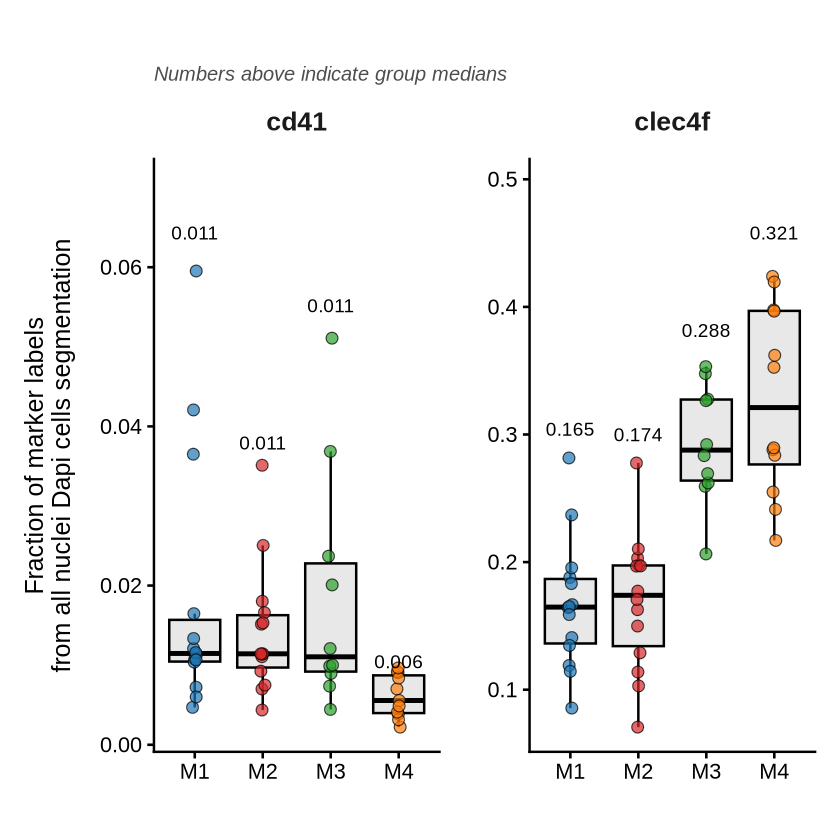

In [64]:
ggplot(plot_data, aes(x = batch_group, y = fraction, group = batch_group)) +
  # Boxes: Light grey background, thin lines for non-bold look
  geom_boxplot(fill = "gray70", alpha = 0.3, outlier.shape = NA, color = "black", linewidth = 0.7) +
  
  # Jitter points: Sized for visibility
  geom_point(
    aes(fill = batch_group),
    position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.1), 
    alpha = 0.7, 
    size = 3, 
    shape = 21, 
    color = "black", 
    stroke = 0.5
  ) + 
  
  # Add numeric Median values above the bars
  stat_summary(
    fun.data = function(x) {
      return(data.frame(
        y = max(x) + (max(x) * 0.08), # Position 8% above the highest point
        label = sprintf("%.3f", median(x))
      ))
    },
    geom = "text",
    family = "Arial",
    size = 4,
    color = "black"
  ) +
  
 # Added scale_y_continuous with expand to force ggplot to add 15% extra blank space at the top of every facet
  facet_wrap(~ phenotype, scales = "free_y") +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = palette_colors) + 
  
  # Theme & Layout
  theme_classic(base_size = 16, base_family = "Arial") + 

  labs(title = "",
       subtitle = "Numbers above indicate group medians",
       x = "",
       y = "Fraction of marker labels\nfrom all nuclei Dapi cells segmentation") +

  theme(
    legend.position = "none",
    plot.subtitle = element_text(face = "italic", size = 12, color = "gray30", margin = margin(b = 15)),
    # Balanced axis title and text sizes
    axis.title.y = element_text(face = "plain", size = 15, margin = margin(r = 15)), # Added right margin to y-axis title
    axis.text = element_text(face = "plain", color = "black", size = 13),
    axis.line = element_line(linewidth = 0.7),
    # Adjusted facet headers
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 16, margin = margin(b = 15)),
    # Extra room to prevent labels from being cut off
    panel.spacing = unit(2, "lines"),
    plot.margin = margin(15, 15, 15, 15)
  )

# Save with Cairo for clean Arial rendering
# ggsave(file.path(image_analysis_results_figs, paste0(MAY12,"cell_labels_fraction_boxplot_clean_final.png")), 
#        width = 13, height = 8, device = png, type = "cairo")

ggsave(
  file.path(image_analysis_results_figs, paste0(JUN06, "_cell_labels_fraction_boxplot_clean_final.png")), 
  width = 13, 
  height = 8, 
  device = "png", 
  type = "cairo", 
  dpi = 300 
)

# Neighbors Analysis - Shuffling

## logger

In [29]:
JUN06 <- date_str(2026, 6, 6)
logs_dir <-  file.path(home_path, "logs")
if(!dir.exists(logs_dir)) { 
    dir.create(logs_dir, recursive = TRUE)
}
log_file <- file.path(logs_dir, paste0(JUN06, "_image_analysis_neighbors_amir_codes_s100a8_log.txt"))
if (file.exists(log_file)) {
  file.remove(log_file)
}


log_appender(appender_tee(log_file, append = TRUE))
# Optional: Make the log layout look very clean
log_layout(layout_glue_generator('[{time}] [{level}] {msg}'))
log_info("Starting 2026 JUN 06 image neighbors analysis Amir's codes....")

[1] TRUE

## Data

In [30]:
names(images_files_markers) %>%  head()

[1] "M1_Series001_clec4f" "M1_Series001_cd41"   "M1_Series001_dapi"  
[4] "M1_Series002_clec4f" "M1_Series002_cd41"   "M1_Series002_dapi"

In [31]:
log_info("Loading combined nuclei data from CSV: {updated_nuclei_full_data_path}")
updated_nuclei_full_data_path <- file.path(image_analysis_results_data, paste0(JUN06, "_cell_markers_and_intensity_quantiles_combined.csv"))
nuclei_full_data <- read.csv(updated_nuclei_full_data_path)  %>% dplyr::select(-X)
nuclei_full_data %>% slice_sample(n=5)
nuclei_full_data %>% dim()

cell_id,image_batch,phenotype,imagenumber,objectnumber,batch,seriesfile,filename_cd41,filename_clec4f,filename_dapi,filename_rgb,location_center_x,location_center_y,number_object_number,file_path,q95_CD41,q90_CD41,q95_CLEC4F,q90_CLEC4F
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
M1_Series003_2107,M1_Series003,none,3,538,M1,Series003,Series003_ch01.tif,Series003_ch02.tif,Series003_ch00.tif,Series003.tif,1493.219,1109.1292,538,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series003,0,0,19.95807,12.92270
M4_Series001_36544,M4_Series001,clec4f,39,140,M4,Series001,P5_M4_CD41_CLEC4F_Series001_ch01.tif,P5_M4_CD41_CLEC4F_Series001_ch02.tif,P5_M4_CD41_CLEC4F_Series001_ch00.tif,P5_M4_CD41_CLEC4F_Series001.tif,1229.139,315.2588,140,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M4_CD41_CLEC4F/P5_M4_CD41_CLEC4F_Series001,0,0,207.44296,122.47276
M1_Series007_4975,M1_Series007,none,7,550,M1,Series007,Series007_ch01.tif,Series007_ch02.tif,Series007_ch00.tif,Series007.tif,1540.625,1074.8992,550,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series007,0,0,55.29176,28.73376
M3_Series004_29829,M3_Series004,clec4f,32,696,M3,Series004,P5_M3_CD41_CLEC4F_Series004_ch01.tif,P5_M3_CD41_CLEC4F_Series004_ch02.tif,P5_M3_CD41_CLEC4F_Series004_ch00.tif,P5_M3_CD41_CLEC4F_Series004.tif,1453.206,1165.3542,696,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M3_CD41_CLEC4F_3_5_26/P5_M3_CD41_CLEC4F_Series004,0,0,128.38415,109.10882
M2_Series015_24200,M2_Series015,none,27,1082,M2,Series015,Series015_ch01.tif,Series015_ch02.tif,Series015_ch00.tif,Series015.tif,1849.570,1859.8599,1082,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M2_CLECF4_CD41_FL/TileScan_014/Series015,0,0,71.67355,56.65556


[1] 48871    19

## Variables

## Main loop functions  easier to maintain 

In [33]:
# -------------------------------------------------------------------------
# 1. Spatial Network Builder
# Takes coordinate data and returns the adjacency matrix and areas.
# -------------------------------------------------------------------------
build_spatial_network <- function(nuclei_sub, max_dist) {
    x <- nuclei_sub$location_center_x
    y <- nuclei_sub$location_center_y
    
    tiles <- tile.list(deldir(x, y))
    names(tiles) <- paste0(names(tiles), ".")
    
    tiles_xy <- paste0(unlist(lapply(tiles, "[[", "x")), "@", unlist(lapply(tiles, "[[", "y")))
    tile2idx <- vecsplit(names(unlist(lapply(tiles, "[[", "x"))), "\\.", 2)
    
    mat <- tapply(rep(1, length(tile2idx)), list(as.numeric(tile2idx), as.numeric(factor(tiles_xy))), mean)
    mat[is.na(mat)] <- 0
    
    touching <- tcrossprod(mat) >= 1 
    xy_coords <- as.matrix(nuclei_sub[, c("location_center_x", "location_center_y")])
    
    touching_nb <- touching & (as.matrix(dist(xy_coords)) < max_dist)
    areas <- sapply(tiles, function(t) poly_area(t$x, t$y))
    
    return(list(touching_nb = touching_nb, areas = areas, tiles = tiles))
}

# -------------------------------------------------------------------------
# 2. Cluster Identifier
# Finds touching target cells and groups them into valid clusters.
# -------------------------------------------------------------------------
identify_clusters <- function(touching_nb, ct, target_type, min_good_targets) {
    target_idx <- which(ct == target_type)
    if (length(target_idx) < 2) return(NULL) # Not enough targets
    
    touching_target <- touching_nb[target_idx, target_idx]
    cc_new <- touching_target
    cc_old <- matrix(FALSE, nrow = dim(cc_new)[1], ncol = dim(cc_new)[2]) 
    
    i <- 1
    while((!all(cc_old == cc_new)) & (i < 100)) {
        cc_old <- cc_new
        cc_new <- crossprod(cc_old, touching_target) > 0 
        i <- i + 1
    }
    
    nuc2target <- as.numeric(factor(apply(as.matrix(cc_new), 1, function(x) paste0(seq_along(x)[x], collapse = ","))))
    names(nuc2target) <- target_idx
    
    good_targets <- names(which(table(nuc2target) > min_good_targets))
    if(length(good_targets) == 0) return(NULL)
    
    # Isolate touching matrix just for the good clusters
    target_vs_all <- touching_nb[target_idx, setdiff(seq_len(ncol(touching_nb)), target_idx)]
    target_touching <- apply(target_vs_all, 2, tapply, nuc2target[rownames(target_vs_all)], sum) > 0
    if (!is.matrix(target_touching)) {
        target_touching <- t(as.matrix(target_touching))
        rownames(target_touching) <- unique(nuc2target) 
    }
    target_touching <- target_touching[as.character(good_targets), , drop = FALSE]
    
    return(list(nuc2target = nuc2target, good_targets = good_targets, target_touching = target_touching))
}

# -------------------------------------------------------------------------
# 3. Fraction & Permutation Calculator
# Handles the real fractions and the shuffling loop.
# -------------------------------------------------------------------------
calculate_fractions_and_shuffles <- function(target_touching, ct, k,
                                              denom_labels, saved_labels,
                                              all_ct_levels) {
    ct_wo_mk <- ct[as.numeric(colnames(target_touching))]

    neighbor_types <- t(apply(
        target_touching, 1,
        function(x) table(factor(ct_wo_mk[x], levels = all_ct_levels))
    ))
    if (!is.matrix(neighbor_types)) return(NULL)

    total_valid <- rowSums(neighbor_types[, denom_labels, drop = FALSE], na.rm = TRUE)

    # FIX: raw division first — do NOT replace NA with 0 here
    raw_fractions <- neighbor_types[, saved_labels, drop = FALSE] / total_valid

    # FIX: valid_mask drops clusters where denominator == 0 (avoids unintended zeros)
    valid_mask <- is.finite(rowSums(raw_fractions)) & (total_valid > 0)
    if (!any(valid_mask)) return(NULL)

    real_fractions           <- raw_fractions[valid_mask, , drop = FALSE]
    colnames(real_fractions) <- paste0("real_frac_", saved_labels)
    target_touching_f        <- target_touching[valid_mask, , drop = FALSE]  # FIX: filter before shuffles

    shuf_mats        <- lapply(saved_labels, function(x) matrix(NA, nrow = sum(valid_mask), ncol = k))
    names(shuf_mats) <- saved_labels

    for (sim_idx in seq_len(k)) {
        shuffled_touching <- target_touching_f[, sample(ncol(target_touching_f)), drop = FALSE]
        neighbor_shuf     <- t(apply(
            shuffled_touching, 1,
            function(x) table(factor(ct_wo_mk[x], levels = all_ct_levels))
        ))

        shuf_total_valid                        <- rowSums(neighbor_shuf[, denom_labels, drop = FALSE], na.rm = TRUE)
        shuf_total_valid[shuf_total_valid == 0] <- 1

        for (label in saved_labels) {
            calc_frac                      <- neighbor_shuf[, label] / shuf_total_valid
            calc_frac[is.na(calc_frac)]    <- 0  # safety net only — denom guard above makes this rare
            shuf_mats[[label]][, sim_idx]  <- calc_frac
        }
    }

    for (label in saved_labels) {
        colnames(shuf_mats[[label]]) <- paste0("shuf_", seq_len(k), "_", label)
    }

    # FIX: return valid_mask so the loop can align good_targets, IL-1b, areas
    return(list(real = as.data.frame(real_fractions), shuf = shuf_mats, valid_mask = valid_mask))
}


compute_il1b_stats <- function(q90_il1b, nuc2target, good_targets, k) {
    if (is.null(q90_il1b) || length(good_targets) == 0) return(NULL)

    target_indices <- as.numeric(names(nuc2target))

    # Real observed mean IL-1b per cluster (FIX: was missing entirely)
    real_mean_il1b <- tapply(q90_il1b[target_indices], nuc2target, mean, na.rm = TRUE)[as.character(good_targets)]

    # Shuffle: permute the full nuclei_s population, fix spatial positions
    shuf_indices_mat <- sapply(seq_len(k), function(x) sample(seq_len(length(q90_il1b))))
    q90_s            <- matrix(q90_il1b[shuf_indices_mat], nrow = length(q90_il1b))

    shuf_il1b_raw <- apply(q90_s[target_indices, , drop = FALSE], 2, function(col) {
        tapply(col, nuc2target, mean, na.rm = TRUE)
    })

    if (!is.matrix(shuf_il1b_raw)) {
        shuf_il1b_mat           <- t(as.matrix(shuf_il1b_raw))
        rownames(shuf_il1b_mat) <- names(tapply(q90_il1b[target_indices], nuc2target, mean))
    } else {
        shuf_il1b_mat <- shuf_il1b_raw
    }

    shuf_il1b_mat           <- shuf_il1b_mat[as.character(good_targets), , drop = FALSE]
    colnames(shuf_il1b_mat) <- paste0("shuf_", seq_len(k), "_Il1b")

    return(list(real_mean = as.numeric(real_mean_il1b), shuf_mat = as.data.frame(shuf_il1b_mat)))
}

## Main loop shuff

In [ ]:
k <- CONFIG$K_PERM
neighbor_type <- CONFIG$NEIGHBOR_TYPE
target_type <- CONFIG$TARGET_TYPE
MAX_DIST <- CONFIG$MAX_DIST
denominator_labels <- c("clec4f",  "none")
saved_labels       <- c("clec4f")
max_size_idx <- CONFIG$MAX_SIZE_IDX
min_good_targets <- CONFIG$MIN_NUM_CLUST
all_ct_levels <- nuclei_full_data %>% pull(phenotype) %>% unique() %>% unlist() %>% as.character()
min_good_targets <- 2
all_clusters_list  <-  list()
## the tissue is less dense than the previous dataset, hence i have increased the max_size_idx to 6000 .
TARGET_SERIES  <-  nuclei_full_data %>% pull(image_batch) %>% unique()

In [35]:
# 1. Single formatted output for the console
cat(sprintf(
  "=== Neighbor Analysis Configuration ===\nIterations (k): %s\nNeighbor Type: %s\nTarget Type: %s\nMAX_DIST: %s\nMax Size Idx: %s\nMin Good Target: %s\nDenominator Labels: %s\nSaved Labels: %s\nAll Cell Types: %s\nTotal Batches: %s\n=======================================\n",
  k, neighbor_type, target_type, MAX_DIST, max_size_idx, min_good_target,
  paste(denominator_labels, collapse = ", "),
  paste(saved_labels, collapse = ", "),
  paste(all_ct_levels, collapse = ", "),
  length(TARGET_SERIES)
))

# 2. Consolidate your logging into two comprehensive entries
log_info("Initialized neighbor analysis. Params: k={k}, neighbor={neighbor_type}, target={target_type}, MAX_DIST={MAX_DIST}, min_target={min_good_target}")
log_info("Analyzing {length(TARGET_SERIES)} batches: {paste(TARGET_SERIES, collapse=', ')}")

=== Neighbor Analysis Configuration ===
Iterations (k): 5000
Neighbor Type: clec4f
Target Type: cd41
MAX_DIST: 100
Max Size Idx: 6000
Min Good Target: 2
Denominator Labels: clec4f, none
Saved Labels: clec4f
All Cell Types: none, clec4f, cd41
Total Batches: 50


In [36]:
heavy_objs <- c("nuclei_sub", "network", "touching_nb_sub", "nuclei_s", 
                "clusters", "stats", "mapped_cells", "img_df")

In [37]:
all_clusters_list <- list()

for (series in TARGET_SERIES) {
    message(paste0("Image start processing: ", series))
    log_info("Processing image: {series}.")

    tryCatch({
        # 1. Subset
        nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)

        # 2. Spatial network
        network <- build_spatial_network(nuclei_sub, MAX_DIST)
        # 3. Filter by cell area

        small_idx       <- which(network$areas < max_size_idx)
        nuclei_s        <- nuclei_sub[small_idx, ]
        touching_nb_sub <- network$touching_nb[small_idx, small_idx]
        dimnames(touching_nb_sub) <- list(seq_along(small_idx), seq_along(small_idx))
        ct <- nuclei_s %>% pull(phenotype)
        log_info("Cell types found: {paste(unique(ct), collapse=', ')}.")

        # 4. Identify clusters
        clusters <- identify_clusters(touching_nb_sub, ct, target_type, min_good_targets)
        if (is.null(clusters)) {
            log_warn("Image {series}: No valid clusters found. Skipping.")
            rm(list = intersect(heavy_objs, ls())); gc(verbose = FALSE); next
        }
        message("Image has ", length(clusters$good_targets), " megakaryocytes!")

        # 5. Fractions & shuffles — same function, different labels passed in
        log_info("Starting neighbor calculations and {k} shuffles for {series}...")
        stats <- calculate_fractions_and_shuffles(
            clusters$target_touching, ct, k,
            denominator_labels, saved_labels, all_ct_levels
        )
        if (is.null(stats)) {
            log_warn("Image {series}: No valid clusters after fraction filtering. Skipping.")
            rm(list = intersect(heavy_objs, ls())); gc(verbose = FALSE); next
        }

        # Align good_targets to valid_mask (drops clusters with zero valid neighbours)
        good_targets_final <- clusters$good_targets[stats$valid_mask]
        log_info("Image {series}: {length(good_targets_final)} clusters pass all filters.")

        # 6. Cluster metadata
        mapped_cells  <- split(names(clusters$nuc2target), clusters$nuc2target)
        nuc_indices   <- as.numeric(names(clusters$nuc2target))
        cluster_areas <- tapply(
            network$areas[small_idx[nuc_indices]], clusters$nuc2target, sum, na.rm = TRUE
        )[as.character(good_targets_final)]

        orig_indices <- sapply(as.character(good_targets_final), function(cid) {
            paste(mapped_cells[[cid]], collapse = ",")
        })
        abs_cell_ids <- sapply(as.character(good_targets_final), function(cid) {
            paste(nuclei_s$cell_id[as.numeric(mapped_cells[[cid]])], collapse = ",")
        })

        # 7. Assemble img_df — no IL-1b block here
        img_df <- data.frame(
            image_batch   = series,
            cluster_id    = seq_along(good_targets_final),  # re-sequenced 1..N
            cluster_cells = orig_indices,
            cluster_area  = as.numeric(cluster_areas),
            stringsAsFactors = FALSE
        )

        img_df <- cbind(img_df, as.data.frame(stats$real))

        for (label in saved_labels) {
            img_df <- cbind(img_df, as.data.frame(stats$shuf[[label]]))
        }

        log_info("Saving {nrow(img_df)} clusters for image: {series}.")
        all_clusters_list[[series]] <- img_df
        rm(list = intersect(heavy_objs, ls())); gc(verbose = FALSE)
        log_info("Memory cleaned for {series}. Moving to next image.")

    }, error = function(e) {
        message("CRITICAL ERROR in ", series, ": ", e$message)
        log_error("CRITICAL ERROR in {series}: {e$message}")
        return(NULL)
    })
}

Image start processing: M1_Series001

Image has 2 megakaryocytes!

Image start processing: M1_Series002

Image has 1 megakaryocytes!

Image start processing: M1_Series003

Image has 3 megakaryocytes!

Image start processing: M1_Series004

Image start processing: M1_Series005

Image has 2 megakaryocytes!

Image start processing: M1_Series006

Image has 3 megakaryocytes!

Image start processing: M1_Series007

Image has 1 megakaryocytes!

Image start processing: M1_Series008

Image has 2 megakaryocytes!

Image start processing: M1_Series009

Image has 1 megakaryocytes!

Image start processing: M1_Series010

Image has 1 megakaryocytes!

Image start processing: M1_Series011

Image has 1 megakaryocytes!

Image start processing: M1_Series012

Image has 1 megakaryocytes!

Image start processing: M1_Series013

Image has 1 megakaryocytes!

Image start processing: M1_Series014

Image has 1 megakaryocytes!

Image start processing: M2_Series002

Image has 2 megakaryocytes!

Image start processing: 

### Combine Results

In [38]:
# Bind everything into one massive dataframe
master_cluster_df_new <- dplyr::bind_rows(all_clusters_list) %>% 
                        mutate(batch=str_extract(image_batch, "M\\d+")) %>% 
                        relocate(batch,cluster_cells,.before = cluster_id)
master_cluster_df_new %>% head()

,image_batch,batch,cluster_cells,cluster_id,cluster_area,real_frac_clec4f,shuf_1_clec4f,shuf_2_clec4f,shuf_3_clec4f,shuf_4_clec4f,⋯,shuf_4991_clec4f,shuf_4992_clec4f,shuf_4993_clec4f,shuf_4994_clec4f,shuf_4995_clec4f,shuf_4996_clec4f,shuf_4997_clec4f,shuf_4998_clec4f,shuf_4999_clec4f,shuf_5000_clec4f
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1...1,M1_Series001,M1,"70,71,79,82,85,90,92,94,95,99,104,106,115",1,33434.83,0.27272727,0.09090909,0.3636364,0.09090909,0.09090909,⋯,0.18181818,0.27272727,0.1818182,0.2727273,0.09090909,0.1818182,0.18181818,0.09090909,0.1818182,0.1818182
2...2,M1_Series001,M1,"313,318,319,320,321,322,323,324,325,326,327,329,330,331,334",2,58969.72,0.18181818,0.36363636,0.3636364,0.36363636,0.36363636,⋯,0.09090909,0.00000000,0.3636364,0.2727273,0.18181818,0.1818182,0.27272727,0.27272727,0.0000000,0.1818182
1...3,M1_Series002,M1,"654,661,674,688,697",1,18305.07,0.33333333,0.33333333,0.3333333,0.33333333,0.22222222,⋯,0.00000000,0.33333333,0.1111111,0.1111111,0.00000000,0.1111111,0.00000000,0.22222222,0.1111111,0.2222222
1...4,M1_Series003,M1,"200,204,216,217,223,233,250",1,23449.12,0.42857143,0.42857143,0.0000000,0.00000000,0.14285714,⋯,0.42857143,0.28571429,0.0000000,0.0000000,0.14285714,0.1428571,0.00000000,0.00000000,0.0000000,0.4285714
2...5,M1_Series003,M1,"376,392,401,403,406,407,429,435,447",2,36874.87,0.14285714,0.00000000,0.4285714,0.28571429,0.14285714,⋯,0.14285714,0.00000000,0.1428571,0.1428571,0.14285714,0.2857143,0.00000000,0.00000000,0.1428571,0.1428571
3...6,M1_Series003,M1,"205,211,214,221,240,243,261,268,270,276,281,295,320,325,335,337",3,52205.56,0.04347826,0.13043478,0.2173913,0.17391304,0.21739130,⋯,0.04347826,0.08695652,0.1739130,0.1739130,0.17391304,0.2608696,0.08695652,0.17391304,0.1739130,0.2608696


In [39]:
master_cluster_df_new %>% pull(batch) %>% table()

.
M1 M2 M3 M4 
20 28 20 10 

In [40]:
JUN06 <- date_str(2026, 6, 6)
master_cluster_df_new_f <- file.path(image_analysis_results_data, paste0(JUN06 ,"_p5_clec4f_neighbors_analysis_shuf.csv"))
write.csv(master_cluster_df_new, master_cluster_df_new_f, row.names = FALSE)

In [41]:
# master_cluster_df_old %>% pull(batch) %>% table()
master_cluster_df_new %>% pull(batch) %>% table()

.
M1 M2 M3 M4 
20 28 20 10 

In [42]:
mk_counts <- master_cluster_df_new %>% 
  dplyr::count(image_batch, name = "n_clusters") %>%
  dplyr::arrange(desc(n_clusters))

# Loop through every row in your summarized dataframe
for (i in 1:nrow(mk_counts)) {
  # Extract the batch name and the cluster count for this specific row
  series <- mk_counts$image_batch[i]
  num_clusters <- mk_counts$n_clusters[i]

  # Print your exact log message!
  cat(sprintf("Image %s has %d valid megakaryocyte clusters.\n", series, num_clusters))
}

Image M2_Series006 has 4 valid megakaryocyte clusters.
Image M3_Series003 has 4 valid megakaryocyte clusters.
Image M3_Series005 has 4 valid megakaryocyte clusters.
Image M1_Series003 has 3 valid megakaryocyte clusters.
Image M1_Series006 has 3 valid megakaryocyte clusters.
Image M2_Series012 has 3 valid megakaryocyte clusters.
Image M3_Series010 has 3 valid megakaryocyte clusters.
Image M1_Series001 has 2 valid megakaryocyte clusters.
Image M1_Series005 has 2 valid megakaryocyte clusters.
Image M1_Series008 has 2 valid megakaryocyte clusters.
Image M2_Series002 has 2 valid megakaryocyte clusters.
Image M2_Series003 has 2 valid megakaryocyte clusters.
Image M2_Series004 has 2 valid megakaryocyte clusters.
Image M2_Series007 has 2 valid megakaryocyte clusters.
Image M2_Series010 has 2 valid megakaryocyte clusters.
Image M2_Series011 has 2 valid megakaryocyte clusters.
Image M2_Series013 has 2 valid megakaryocyte clusters.
Image M2_Series014 has 2 valid megakaryocyte clusters.
Image M2_S

In [43]:
mk_counts_batch <- master_cluster_df_new %>% 
  dplyr::count(batch, name = "n_clusters") %>%
  dplyr::arrange(desc(n_clusters))

# Loop through every row in your summarized dataframe
for (i in 1:nrow(mk_counts_batch)) {
  
  # Extract the batch name and the cluster count for this specific row
  series <- mk_counts_batch$batch[i]
  num_clusters <- mk_counts_batch$n_clusters[i]
  
  # Print your exact log message!
  cat(sprintf("Image %s has %d valid megakaryocyte clusters.\n", series, num_clusters))
}

Image M2 has 28 valid megakaryocyte clusters.
Image M1 has 20 valid megakaryocyte clusters.
Image M3 has 20 valid megakaryocyte clusters.
Image M4 has 10 valid megakaryocyte clusters.


In [44]:
total_MKS <- sum(mk_counts$n_clusters)
cat(sprintf("Total valid megakaryocyte clusters across all images: %d\n", total_MKS))

Total valid megakaryocyte clusters across all images: 78


In [46]:
master_cluster_df_new %>% dim()

[1]   78 5006

### Save Results

In [ ]:
# write.csv(master_cluster_df, file.path(image_analysis_results_data, paste0(MAY27 ,"_all_clusters_neighbor_analysis.csv")))

### load data 

In [ ]:
JUN06 <- date_str(2026, 6, 6)

# Load Neighbors Analysis Results

In [51]:
updated_nuclei_full_data_path <- file.path(image_analysis_results_data, paste0(JUN06, "_cell_markers_and_intensity_quantiles_combined.csv"))
nuclei_full_data <- read.csv(updated_nuclei_full_data_path)  %>% dplyr::select(-X)
nuclei_full_data %>% slice_sample(n=5)
nuclei_full_data %>% dim()

cell_id,image_batch,phenotype,imagenumber,objectnumber,batch,seriesfile,filename_cd41,filename_clec4f,filename_dapi,filename_rgb,location_center_x,location_center_y,number_object_number,file_path,q95_CD41,q90_CD41,q95_CLEC4F,q90_CLEC4F
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
M2_Series002_11549,M2_Series002,none,15,301,M2,Series002,Series002_ch01.tif,Series002_ch02.tif,Series002_ch00.tif,Series002.tif,1631.45553,512.5336,301,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M2_CLECF4_CD41_FL/TileScan_002/Series002,0,0,81.6520466,71.57301192
M2_Series003_13321,M2_Series003,clec4f,16,807,M2,Series003,Series003_ch01.tif,Series003_ch02.tif,Series003_ch00.tif,Series003.tif,866.76373,1570.1723,807,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M2_CLECF4_CD41_FL/TileScan_003/Series003,0,0,229.1326469,197.51132886
M1_Series008_6129,M1_Series008,none,8,1012,M1,Series008,Series008_ch01.tif,Series008_ch02.tif,Series008_ch00.tif,Series008.tif,606.25037,1994.6392,1012,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M1_CLEC4F_CD41_Liver/M1_P5_FL_Series008,0,0,14.7921110,7.66661627
M4_Series003_38387,M4_Series003,none,41,315,M4,Series003,P5_M4_CD41_CLEC4F_Series003_ch01.tif,P5_M4_CD41_CLEC4F_Series003_ch02.tif,P5_M4_CD41_CLEC4F_Series003_ch00.tif,P5_M4_CD41_CLEC4F_Series003.tif,51.77551,616.4166,315,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M4_CD41_CLEC4F/P5_M4_CD41_CLEC4F_Series003,0,0,30.9239799,14.86010409
M4_Series005_40629,M4_Series005,none,43,313,M4,Series005,P5_M4_CD41_CLEC4F_Series005_ch01.tif,P5_M4_CD41_CLEC4F_Series005_ch02.tif,P5_M4_CD41_CLEC4F_Series005_ch00.tif,P5_M4_CD41_CLEC4F_Series005.tif,1270.90292,527.0000,313,/mc_disk1/data/Maiia_hemato_images/P5_CLEC4F_CD41/images_for_cellprofiler/P5_M4_CD41_CLEC4F/P5_M4_CD41_CLEC4F_Series005,0,0,0.5787492,0.04021349


[1] 48871    19

In [50]:
master_cluster_df_new_f <- file.path(image_analysis_results_data, paste0(JUN06 ,"_p5_clec4f_neighbors_analysis_shuf.csv"))
master_cluster_df <- read.csv(master_cluster_df_new_f)
master_cluster_df %>% slice_sample(n=5)

image_batch,batch,cluster_cells,cluster_id,cluster_area,real_frac_clec4f,shuf_1_clec4f,shuf_2_clec4f,shuf_3_clec4f,shuf_4_clec4f,⋯,shuf_4991_clec4f,shuf_4992_clec4f,shuf_4993_clec4f,shuf_4994_clec4f,shuf_4995_clec4f,shuf_4996_clec4f,shuf_4997_clec4f,shuf_4998_clec4f,shuf_4999_clec4f,shuf_5000_clec4f
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
M3_Series007,M3,"522,535,542,563",2,12747.102,0.5000000,0.0000000,0.2500000,0.3750000,0.1250000,⋯,0.37500000,0.2500000,0.37500000,0.3750000,0.2500000,0.2500000,0.5000000,0.37500000,0.6250000,0.3750000
M3_Series005,M3,"596,598,605,607,613",2,12733.587,0.4285714,0.5714286,0.4285714,0.2857143,0.1428571,⋯,0.42857143,0.4285714,0.42857143,0.4285714,0.5714286,0.4285714,0.1428571,0.42857143,0.2857143,0.2857143
M4_Series011,M4,"623,629,633",2,9776.005,0.5000000,0.5000000,0.5000000,0.7500000,0.5000000,⋯,0.25000000,0.0000000,0.00000000,0.5000000,0.0000000,0.5000000,0.5000000,0.50000000,0.2500000,0.2500000
M3_Series010,M3,"456,472,480,491,499,510,511,512,531",2,23776.064,0.5000000,0.1666667,0.1666667,0.2500000,0.3333333,⋯,0.33333333,0.5000000,0.33333333,0.1666667,0.1666667,0.5833333,0.4166667,0.41666667,0.2500000,0.3333333
M1_Series009,M1,"244,263,266,288,292,295,299,316,326,331,339,350,357,389",1,52617.210,0.2666667,0.3333333,0.1333333,0.2000000,0.2000000,⋯,0.06666667,0.0000000,0.06666667,0.2666667,0.3333333,0.1333333,0.1333333,0.06666667,0.2000000,0.2666667


In [65]:
master_cluster_df %>% colnames()

[1] "image_batch"      "batch"            "cluster_cells"   
   [4] "cluster_id"       "cluster_area"     "real_frac_clec4f"
   [7] "shuf_1_clec4f"    "shuf_2_clec4f"    "shuf_3_clec4f"   
  [10] "shuf_4_clec4f"    "shuf_5_clec4f"    "shuf_6_clec4f"   
  [13] "shuf_7_clec4f"    "shuf_8_clec4f"    "shuf_9_clec4f"   
  [16] "shuf_10_clec4f"   "shuf_11_clec4f"   "shuf_12_clec4f"  
  [19] "shuf_13_clec4f"   "shuf_14_clec4f"   "shuf_15_clec4f"  
  [22] "shuf_16_clec4f"   "shuf_17_clec4f"   "shuf_18_clec4f"  
  [25] "shuf_19_clec4f"   "shuf_20_clec4f"   "shuf_21_clec4f"  
  [28] "shuf_22_clec4f"   "shuf_23_clec4f"   "shuf_24_clec4f"  
  [31] "shuf_25_clec4f"   "shuf_26_clec4f"   "shuf_27_clec4f"  
  [34] "shuf_28_clec4f"   "shuf_29_clec4f"   "shuf_30_clec4f"  
  [37] "shuf_31_clec4f"   "shuf_32_clec4f"   "shuf_33_clec4f"  
  [40] "shuf_34_clec4f"   "shuf_35_clec4f"   "shuf_36_clec4f"  
  [43] "shuf_37_clec4f"   "shuf_38_clec4f"   "shuf_39_clec4f"  
  [46] "shuf_40_clec4f"   "shuf_41_clec4f"   "shuf_42_clec4f"  
  [49] "shuf_43_clec4f"   "shuf_44_clec4f"   "shuf_45_clec4f"  
  [52] "shuf_46_clec4f"   "shuf_47_clec4f"   "shuf_48_clec4f"  
  [55] "shuf_49_clec4f"   "shuf_50_clec4f"   "shuf_51_clec4f"  
  [58] "shuf_52_clec4f"   "shuf_53_clec4f"   "shuf_54_clec4f"  
  [61] "shuf_55_clec4f"   "shuf_56_clec4f"   "shuf_57_clec4f"  
  [64] "shuf_58_clec4f"   "shuf_59_clec4f"   "shuf_60_clec4f"  
  [67] "shuf_61_clec4f"   "shuf_62_clec4f"   "shuf_63_clec4f"  
  [70] "shuf_64_clec4f"   "shuf_65_clec4f"   "shuf_66_clec4f"  
  [73] "shuf_67_clec4f"   "shuf_68_clec4f"   "shuf_69_clec4f"  
  [76] "shuf_70_clec4f"   "shuf_71_clec4f"   "shuf_72_clec4f"  
  [79] "shuf_73_clec4f"   "shuf_74_clec4f"   "shuf_75_clec4f"  
  [82] "shuf_76_clec4f"   "shuf_77_clec4f"   "shuf_78_clec4f"  
  [85] "shuf_79_clec4f"   "shuf_80_clec4f"   "shuf_81_clec4f"  
  [88] "shuf_82_clec4f"   "shuf_83_clec4f"   "shuf_84_clec4f"  
  [91] "shuf_85_clec4f"   "shuf_86_clec4f"   "shuf_87_clec4f"  
  [94] "shuf_88_clec4f"   "shuf_89_clec4f"   "shuf_90_clec4f"  
  [97] "shuf_91_clec4f"   "shuf_92_clec4f"   "shuf_93_clec4f"  
 [100] "shuf_94_clec4f"   "shuf_95_clec4f"   "shuf_96_clec4f"  
 [103] "shuf_97_clec4f"   "shuf_98_clec4f"   "shuf_99_clec4f"  
 [106] "shuf_100_clec4f"  "shuf_101_clec4f"  "shuf_102_clec4f" 
 [109] "shuf_103_clec4f"  "shuf_104_clec4f"  "shuf_105_clec4f" 
 [112] "shuf_106_clec4f"  "shuf_107_clec4f"  "shuf_108_clec4f" 
 [115] "shuf_109_clec4f"  "shuf_110_clec4f"  "shuf_111_clec4f" 
 [118] "shuf_112_clec4f"  "shuf_113_clec4f"  "shuf_114_clec4f" 
 [121] "shuf_115_clec4f"  "shuf_116_clec4f"  "shuf_117_clec4f" 
 [124] "shuf_118_clec4f"  "shuf_119_clec4f"  "shuf_120_clec4f" 
 [127] "shuf_121_clec4f"  "shuf_122_clec4f"  "shuf_123_clec4f" 
 [130] "shuf_124_clec4f"  "shuf_125_clec4f"  "shuf_126_clec4f" 
 [133] "shuf_127_clec4f"  "shuf_128_clec4f"  "shuf_129_clec4f" 
 [136] "shuf_130_clec4f"  "shuf_131_clec4f"  "shuf_132_clec4f" 
 [139] "shuf_133_clec4f"  "shuf_134_clec4f"  "shuf_135_clec4f" 
 [142] "shuf_136_clec4f"  "shuf_137_clec4f"  "shuf_138_clec4f" 
 [145] "shuf_139_clec4f"  "shuf_140_clec4f"  "shuf_141_clec4f" 
 [148] "shuf_142_clec4f"  "shuf_143_clec4f"  "shuf_144_clec4f" 
 [151] "shuf_145_clec4f"  "shuf_146_clec4f"  "shuf_147_clec4f" 
 [154] "shuf_148_clec4f"  "shuf_149_clec4f"  "shuf_150_clec4f" 
 [157] "shuf_151_clec4f"  "shuf_152_clec4f"  "shuf_153_clec4f" 
 [160] "shuf_154_clec4f"  "shuf_155_clec4f"  "shuf_156_clec4f" 
 [163] "shuf_157_clec4f"  "shuf_158_clec4f"  "shuf_159_clec4f" 
 [166] "shuf_160_clec4f"  "shuf_161_clec4f"  "shuf_162_clec4f" 
 [169] "shuf_163_clec4f"  "shuf_164_clec4f"  "shuf_165_clec4f" 
 [172] "shuf_166_clec4f"  "shuf_167_clec4f"  "shuf_168_clec4f" 
 [175] "shuf_169_clec4f"  "shuf_170_clec4f"  "shuf_171_clec4f" 
 [178] "shuf_172_clec4f"  "shuf_173_clec4f"  "shuf_174_clec4f" 
 [181] "shuf_175_clec4f"  "shuf_176_clec4f"  "shuf_177_clec4f" 
 [184] "shuf_178_clec4f"  "shuf_179_clec4f"  "shuf_180_clec4f" 
 [187] "shuf_181_clec4f"  "shuf_182

## Calculation- Mean Observed/Expected
### Neighbors fraction Mac -> Clec4f

In [66]:
batch_means_df <- master_cluster_df %>% 
  # 1. Calculate expected fraction per cluster
  dplyr::rowwise() %>%
  # FIXED: Explicitly use dplyr::mutate so plyr doesn't crash it
  dplyr::mutate(expected_frac_clec4f = base::mean(c_across(starts_with("shuf_")), na.rm = TRUE)) %>%
  dplyr::ungroup() %>%
  
  # 2. Group by batch
  dplyr::group_by(batch) %>%
  
  # 3. Summarise
  dplyr::summarise(
    n_clusters = n(), 
    mean_observed = base::mean(real_frac_clec4f, na.rm = TRUE),
    mean_expected = base::mean(expected_frac_clec4f, na.rm = TRUE),
      # wilcox_p_val = suppressWarnings(
      #   stats::wilcox.test(real_fraction, expected_fraction, paired = TRUE)$p.value
      # ),
    dplyr::across(starts_with("shuf_"), ~base::mean(.x, na.rm = TRUE), .names = "shuf_mean_{.col}"),
    .groups = "drop"
  ) %>%
  
  # 4. Perform batch-level permutation statistics
  dplyr::rowwise() %>%
  dplyr::mutate(
    shuf_vals = list(c_across(starts_with("shuf_mean_"))),
    perm_p_val = sum(unlist(shuf_vals) >= mean_observed) / length(unlist(shuf_vals)),
    effect_size = (mean_observed - mean_expected) / sd(unlist(shuf_vals)),
    null_ci_lower = quantile(unlist(shuf_vals), 0.025),
    null_ci_upper = quantile(unlist(shuf_vals), 0.975),
  ) %>%
  dplyr::ungroup() %>% 
  
  # 5. Reorganize
  dplyr::relocate(perm_p_val,  effect_size, null_ci_lower, null_ci_upper,   .after = mean_expected) # wilcox_p_val




In [75]:
print(batch_means_df %>%
  pivot_longer(
    cols = c(mean_observed, mean_expected),
    names_to = "fraction_type",
    values_to = "mean_value"
  ) %>% 
  select(any_of(c("batch","fraction_type","mean_value"))) %>% 
    mutate(
    # Use the lowercase strings that 'pivot_longer' created
    fraction_type = ifelse(fraction_type == "mean_observed", "Observed", "Expected"),
    fraction_type = factor(fraction_type, levels = c("Expected", "Observed"))
  ))

# A tibble: 8 × 3
  batch fraction_type mean_value
  <chr> <fct>              <dbl>
1 M1    Observed           0.303
2 M1    Expected           0.197
3 M2    Observed           0.201
4 M2    Expected           0.187
5 M3    Observed           0.367
6 M3    Expected           0.302
7 M4    Observed           0.609
8 M4    Expected           0.358


#### one sample T-test on Z-score (effect size - calculation )

(mean_observed - mean_expected) / sd(unlist(shuf_vals))

In [85]:
# Run a One-Sample T-Test on your 5 effect sizes
# mu = 0 sets your "random chance" baseline
# alternative = "greater" asks if the clustering is strictly positive
t_test_results_clec4f <- t.test(batch_means_df$effect_size, mu = 0, alternative = "greater")

# Print the full statistical output
message("One-Sample T-Test Results for Batch-Level Effect Sizes Mac shuffle Analysis")
print(t_test_results_clec4f)

One-Sample T-Test Results for Batch-Level Effect Sizes Mac shuffle Analysis




	One Sample t-test

data:  batch_means_df$effect_size
t = 2.8265, df = 3, p-value = 0.03319
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.4223995       Inf
sample estimates:
mean of x 
 2.523591 



## Z-score standard scale (effect size) & t-test

In [56]:
JUN06 <- date_str(2026, 6, 6)
figs_JUN06  <-  file.path(image_analysis_results_figs, paste0(JUN06, "_figs_shuff"))
if(!dir.exists(figs_JUN06)) {
    dir.create(figs_JUN06, recursive = TRUE)
}

In [80]:
# Pivot and clean
df_neigh_shuf <- batch_means_df %>%
  pivot_longer(
    cols = c(mean_observed, mean_expected),
    names_to = "fraction_type",
    values_to = "mean_value"
  ) %>% dplyr::select(-starts_with("shuf_mean_")) %>%
  mutate(
    # Use the lowercase strings that 'pivot_longer' created
    fraction_type = ifelse(fraction_type == "mean_observed", "Observed", "Expected"),
    fraction_type = factor(fraction_type, levels = c("Expected", "Observed"))
  )


In [81]:
print(df_neigh_shuf)

# A tibble: 8 × 9
  batch n_clusters perm_p_val effect_size null_ci_lower null_ci_upper shuf_vals
  <chr>      <int>      <dbl>       <dbl>         <dbl>         <dbl> <list>   
1 M1            20     0.0048       2.67          0.125         0.278 <dbl>    
2 M1            20     0.0048       2.67          0.125         0.278 <dbl>    
3 M2            28     0.287        0.544         0.138         0.237 <dbl>    
4 M2            28     0.287        0.544         0.138         0.237 <dbl>    
5 M3            20     0.022        2.03          0.239         0.366 <dbl>    
6 M3            20     0.022        2.03          0.239         0.366 <dbl>    
7 M4            10     0            4.84          0.261         0.465 <dbl>    
8 M4            10     0            4.84          0.261         0.465 <dbl>    
# ℹ 2 more variables: fraction_type <fct>, mean_value <dbl>


In [82]:

write_csv(df_neigh_shuf, file.path(image_analysis_results_data, paste0(JUN06, "_plot_data_clec4f.csv")))


# publication plot Clec4f -> MKS

In [ ]:
library(patchwork)
library(ggrepel)
library(grid)
# Staining design: Neutral gray for control, soft alpha-green for tissue reality
fill_palette <- c( "Expected" = "gray95", "Observed" = scales::alpha("#A6D96A", 0.5))


JUN06 <- date_str(2026, 6, 6)
figs_JUN06_shuff_clec4f <- file.path(
  image_analysis_results_figs,
  paste0(JUN06, "_shuff_clec4f_pub")
)
if (!dir.exists(figs_JUN06_shuff_clec4f)) {
  dir.create(figs_JUN06_shuff_clec4f, recursive = TRUE)
}

p_val_clec4f <- paste0("p = ", formatC(t_test_results_clec4f$p.value, format = "f", digits = 3))


theme_publication <- function(...) {
  theme_classic(...) +
    theme(
      axis.line       = element_line(color = "black", linewidth = 0.6),
      axis.ticks      = element_line(color = "black", linewidth = 0.5),
      axis.text       = element_text(color = "black", size = 11),
      axis.title.y    = element_text(color = "black", size = 11, face = "bold",
                                     margin = margin(r = 6)),
      axis.title.x    = element_blank(),
      panel.border    = element_blank(),
      legend.position = "none",                          # was being overridden
      plot.margin     = margin(t = 20, r = 30, b = 10, l = 10)
    )
}

# ==========================================
# BAR PLOT
# ==========================================
pA <- ggplot(df_neigh_shuf, aes(x = fraction_type, y = mean_value)) +

  # 1. Background bars — FIX 2: map fill to fraction_type so scale_fill_manual fires.
  #    Previously hardcoded fill = "gray90" with no aesthetic mapping meant
  #    scale_fill_manual was dead code and fill_palette was never applied.
  stat_summary(aes(fill = fraction_type),
    fun = mean, geom = "bar", 
    color = "black", 
    linewidth = 0.5, 
    width = 0.6) +
  # 2. ±SE error bars
  stat_summary(fun.data = mean_se, 
    geom = "errorbar", 
    color = "black", 
    linewidth = 0.6, 
    width = 0.15) +
  # 3. Paired-batch connecting lines

  geom_line(aes(group = batch), 
    color = "gray60", 
    linewidth = 0.5, 
    alpha = 0.8,
    position = position_identity()) +
  # 4. Individual data points
  geom_point(color = "black", 
    size = 2.5, 
    shape = 16, 
    position = position_identity()) +
  # 5. p-value annotation — anchored to y = 195 (fixed axis ceiling = 200)
  #    rather than max(data) * 0.95, which shifts with the data distribution.
  scale_fill_manual(values = fill_palette , guide = "none") +

  scale_y_continuous(
    limits = c(0, 0.7), 
    expand = c(0, 0), 
    breaks = seq(0, 0.7, by = 0.1)) +

  scale_x_discrete(
    expand = expansion(mult = c(0.4, 0.4)),
    labels = c("Expected", "Observed")) +

  coord_cartesian(clip = "off") +
  labs(title = NULL, x = NULL, y = "Fraction") +

  annotate( "text", 
    x = 1.5, 
    y = 0.65, 
    label = p_val_clec4f, 
    fontface = "bold",
     size = 4 ) +

  theme_publication()   # called once, last — owns all theme state
# ==========================================
# MULTI-FORMAT EXPORT
# ==========================================
message("Saving plots...")
cairo_pdf(file.path(figs_JUN06_shuff_clec4f, paste0(JUN06, "_CLEC4F_Barplot.pdf")), width = 3.2, height = 6)
print(pA)
dev.off()

png(file.path(figs_JUN06_shuff_clec4f, paste0(JUN06, "_CLEC4F_Barplot.png")), width = 3.2, height = 6, units = "in", res = 600)
print(pA)
dev.off()

message("Export complete.")

Saving plots...



agg_record_1846337351 
                    2

agg_record_1846337351 
                    2

Export complete.



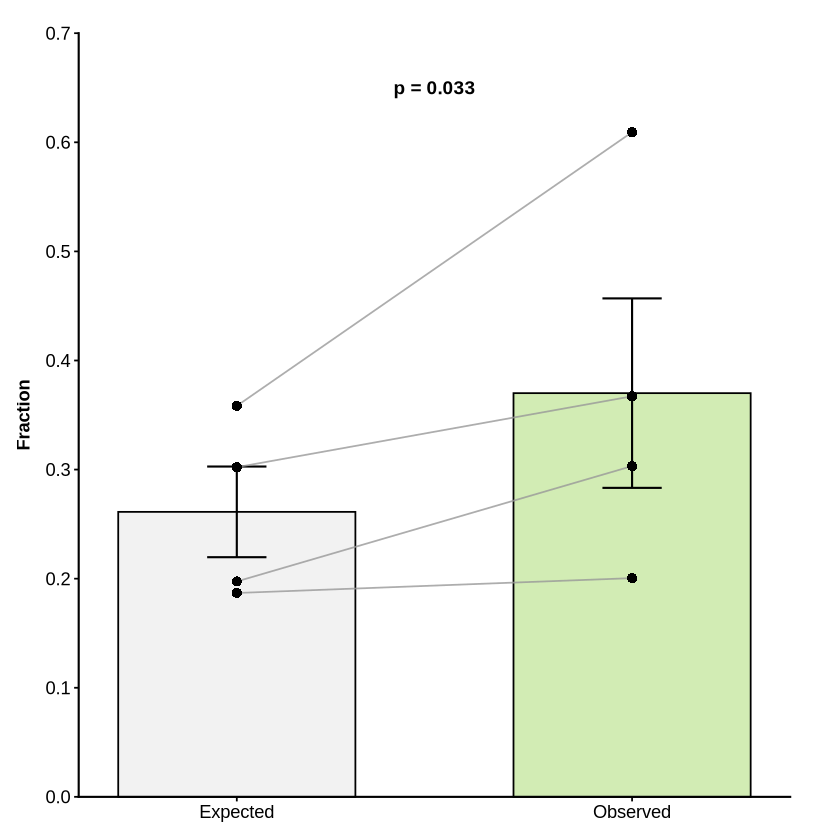

In [140]:
pA

# Tiles plot

In [107]:
normalize_channel <- function(mat, gamma = 0.6, cap_percentile = 0.999) {
    if (is.null(mat)) return(NULL)
    mx <- quantile(mat, probs = cap_percentile, na.rm = TRUE)
    if (is.na(mx) || mx <= 0) mx <- max(mat, na.rm = TRUE)
    if (mx <= 0) mx <- 1 
    
    mat[mat > mx] <- mx
    mat <- mat / mx
    mat[is.na(mat)] <- 0
    mat <- mat ^ gamma 
    
    #ADD THESE TWO LINES HERE TO KILL THE CRASH permanently:
    mat[is.nan(mat)]      <- 0   # Convert any 0/0 division anomalies to black (0)
    mat[is.infinite(mat)] <- 0   # Convert any infinity bounds to black (0)
    
    return(mat)
}

In [108]:
create_rgb_array <- function(r_mats = list(), g_mats = list(), b_mats = list(), x_dim, y_dim) {
    rgb_arr <- array(0, dim = c(y_dim, x_dim, 3))
    
    add_layers <- function(arr, mat_list, channel_idx) {
        for (mat in mat_list) {
            if (!is.null(mat) && length(mat) > 1) {
                # Transpose and flip to align rasterImage with base plot coordinates
                mat_t <- t(mat)
                mat_t <- mat_t[y_dim:1, , drop = FALSE]
                arr[,,channel_idx] <- arr[,,channel_idx] + mat_t
            }
        }
        return(arr)
    }
    
    rgb_arr <- add_layers(rgb_arr, r_mats, 1)
    rgb_arr <- add_layers(rgb_arr, g_mats, 2)
    rgb_arr <- add_layers(rgb_arr, b_mats, 3)
    
    # Clamp additive peaks to 1 (pure white)
    rgb_arr[rgb_arr > 1] <- 1
    return(rgb_arr)
}

In [109]:

get_valid_cluster_mask <- function(nuclei_sub,
                                   max_dist         = CONFIG$MAX_DIST,
                                   min_good_targets = CONFIG$MIN_NUM_CLUST,
                                   target_type       = CONFIG$TARGET_TYPE) {

    # Guard: catch unresolved CONFIG values before they silently break the network
    if (is.null(max_dist) ) {
        warning("get_valid_cluster_mask: max_dist is NULL/invalid — defaulting to 50. ",
                "Set CONFIG$MAX_DIST or pass max_dist explicitly.")
        max_dist <- 100
    }
    if (is.null(min_good_targets) ){
        warning("get_valid_cluster_mask: min_good_targets is NULL/invalid — defaulting to 2.")
        min_good_targets <- 2
    }

    # Single source of truth — phenotype labels always from nuclei_sub
    ct         <- tolower(trimws(as.character(nuclei_sub$phenotype)))
    valid_mask <- rep(FALSE, length(ct))

    cd41_pos <- which(ct == "cd41")
    message(sprintf("  [cluster_mask] %d cd41 cells found in nuclei_sub (max_dist=%.0f, min_good_targets=%d)",
                    length(cd41_pos), max_dist, min_good_targets))

    if (length(cd41_pos) < 2) {
        message("  [cluster_mask] < 2 cd41 cells — returning empty mask")
        return(valid_mask)
    }

    net    <- build_spatial_network(nuclei_sub, max_dist = max_dist)
    clusts <- identify_clusters(
        net$touching_nb,
        ct,
        target_type      = target_type,
        min_good_targets = min_good_targets
    )

    if (is.null(clusts)) {
        message("  [cluster_mask] identify_clusters returned NULL — no valid clusters in this image")
        return(valid_mask)
    }

    message(sprintf("  [cluster_mask] %d good cluster(s) found (IDs: %s)",
                    length(clusts$good_targets),
                    paste(clusts$good_targets, collapse = ", ")))

    # names(nuc2target) = integer positions of cd41 cells in ct (as character)
    # cd41_pos          = same values, since both come from which(ct == "cd41")
    in_map     <- cd41_pos[as.character(cd41_pos) %in% names(clusts$nuc2target)]
    cluster_id <- clusts$nuc2target[as.character(in_map)]
    confirmed  <- in_map[as.character(cluster_id) %in% as.character(clusts$good_targets)]

    message(sprintf("  [cluster_mask] %d cluster MK tiles will receive vivid border",
                    length(confirmed)))

    valid_mask[confirmed] <- TRUE
    valid_mask
}


In [110]:
plot_composite_tiles_colored <- function(rgb_arr, tiles, cell_types, nuclei_sub,
                                         output_path, x_dim, y_dim, width, height,
                                         with_tiles = TRUE, tile_alpha = 0.15,
                                         color_palette = type_colors_1,
                                         neighbor_type = CONFIG$NEIGHBOR_TYPE,
                                         target_type = CONFIG$TARGET_TYPE,
                                         ct_types = CONFIG$CT_TYPES
                                         ) {
    png(output_path, height = height, width = width, res = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")

    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim),
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")

    # ── Fluorescent composite background (untouched) ───────────────────────────
    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5,
                xright = x_dim + 0.5, ytop = y_dim + 0.5)

    if (with_tiles && !is.null(cell_types)) {

        ctypes_clean <- tolower(trimws(as.character(cell_types)))
        type_colors  <- color_palette

        # Determine which CD41 cells belong to a real cluster.
        # Mask is indexed by nuclei_sub row position (= tile index).
        cluster_mk_mask <- get_valid_cluster_mask(nuclei_sub, min_good_targets = 2)

        # ── LAYER 1: Baseline / none + singleton (unclustered) CD41 ─────────────
        # Any cell that is not f4_80, s100a8, OR a valid cluster cd41 goes here.
        none_indices <- which(
            ctypes_clean == "none" |
            !(ctypes_clean %in% ct_types) |
            (ctypes_clean == target_type & !cluster_mk_mask)          # singleton MKs
        )
        for (i in none_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y,
                    col = NA, border = type_colors["none"], lwd = 0.5)
        }

        # ── LAYER 2: F4/80 Macrophages ───────────────────────────────────────────
        f480_indices <- which(ctypes_clean == neighbor_type)
        for (i in f480_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y,
                    col = NA, border = type_colors[neighbor_type], lwd = 1.5)
        }


        # ── LAYER 3: Valid-cluster CD41 MKs only ──────────────────────────────────
        valid_cluster_cd41_indices <- which(ctypes_clean == target_type & cluster_mk_mask)
        for (i in valid_cluster_cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y,
                    col = NA, border = type_colors[target_type], lwd = 1.5)
        }
    }
    dev.off()
}

In [ ]:
plot_composite_pdf_tiles_colored <- function(rgb_arr, tiles, cell_types, nuclei_sub,
                                              output_path, x_dim, y_dim, width, height,
                                              with_tiles = TRUE, tile_alpha = 0.15,
                                              color_palette = type_colors_1,
                                              neighbor_type = CONFIG$NEIGHBOR_TYPE,
                                              target_type = CONFIG$TARGET_TYPE,
                                              ct_types = CONFIG$CT_TYPES) {
    cairo_pdf(output_path, height = height / 300, width = width / 300,
              fallback_resolution = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")

    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim),
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")

    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5,
                xright = x_dim + 0.5, ytop = y_dim + 0.5)

    if (with_tiles && !is.null(cell_types)) {

        ctypes_clean <- tolower(trimws(as.character(cell_types)))
        type_colors  <- color_palette

        cluster_mk_mask <- get_valid_cluster_mask(nuclei_sub, min_good_targets = 2)

        # ── LAYER 1: Baseline + singleton CD41 ───────────────────────────────────
        none_indices <- which(
            ctypes_clean == "none" |
            !(ctypes_clean %in% ct_types) |
            (ctypes_clean == target_type & !cluster_mk_mask)
        )
        for (i in none_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y,
                    col = NA, border = type_colors["none"], lwd = 0.5)
        }

        # ── LAYER 2: F4/80 ────────────────────────────────────────────────────────
        f480_indices <- which(ctypes_clean == neighbor_type)
        for (i in f480_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y,
                    col = NA, border = type_colors[neighbor_type], lwd = 1.5)
        }



        # ── LAYER 3: Valid-cluster CD41 MKs only ──────────────────────────────────
        valid_cluster_cd41_indices <- which(ctypes_clean == target_type & cluster_mk_mask)
        for (i in valid_cluster_cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y,
                    col = NA, border = type_colors[target_type], lwd = 1.5)
        }
    }
    dev.off()
}


In [133]:

export_publication_panels_final <- function(nuclei_sub, data_sub, tiles, cell_types,
                                             output_prefix,
                                             image_height = 2048, image_width = 2048,
                                             gamma = 0.6, with_tiles = TRUE) {

    cell_types_clean <- tolower(trimws(as.character(cell_types)))
    map_colors       <- type_colors_1

    # Channel detection
    ch_dapi   <- grep("dapi",   names(data_sub), ignore.case = TRUE, value = TRUE)[1]
    ch_cd41   <- grep("cd41",   names(data_sub), ignore.case = TRUE, value = TRUE)[1]
    ch_clec4f  <- grep("clec4f",  names(data_sub), ignore.case = TRUE, value = TRUE)[1]

    # Normalization
    mat_dapi   <- normalize_channel(data_sub[[ch_dapi]],   gamma = gamma)
    mat_cd41   <- normalize_channel(data_sub[[ch_cd41]],   gamma = gamma)
    mat_clec4f  <- normalize_channel(data_sub[[ch_clec4f]],  gamma = gamma)

    ref_mat <- Filter(Negate(is.null), list(mat_dapi,  mat_cd41, mat_clec4f))[[1]]
    x_dim   <- nrow(ref_mat)
    y_dim   <- ncol(ref_mat)

    # ── Coloured helper — nuclei_sub passed through for cluster detection ──────
    save_comp_colored <- function(suffix, r = list(), g = list(), b = list(),
                                  cell_types_for_tiles = cell_types_clean) {
        arr <- create_rgb_array(r, g, b, x_dim, y_dim)

        plot_composite_tiles_colored(
            rgb_arr     = arr,
            tiles       = tiles,
            cell_types  = cell_types_for_tiles,
            nuclei_sub  = nuclei_sub,                 # ← cluster detection key
            output_path = paste0(output_prefix, suffix, ".png"),
            x_dim = x_dim, y_dim = y_dim,
            width = image_width, height = image_height, with_tiles = with_tiles
        )
        plot_composite_pdf_tiles_colored(
            rgb_arr     = arr,
            tiles       = tiles,
            cell_types  = cell_types_for_tiles,
            nuclei_sub  = nuclei_sub,                 # ← cluster detection key
            output_path = paste0(output_prefix, suffix, ".pdf"),
            x_dim = x_dim, y_dim = y_dim,
            width = image_width, height = image_height, with_tiles = with_tiles
        )
    }


    save_comp_colored("_tiles_colored",
              r = list( mat_cd41),
              g = list(mat_clec4f, mat_cd41),
              b = list(mat_dapi, mat_cd41))
                                             }


In [127]:
series_panel <- "M3_Series003"
all_markers <- CONFIG$MARKERS_ALL


In [128]:
nuclei_sub1 <- nuclei_full_data %>% dplyr::filter(image_batch == series_panel)
tesselation <- deldir(nuclei_sub1$location_center_x, nuclei_sub1$location_center_y)
tiles1 <- tile.list(tesselation)
cell_types1 <-  nuclei_sub1  %>% pull(phenotype)
data_sub1  <-  load_series_matrices(series_panel, all_markers, images_files_markers)
names(data_sub1)

[1] "dapi"   "clec4f" "cd41"

In [135]:


        
type_colors_1 <- c(
            "cd41"   = "#FFFF00",       # Electric Neon Orange/Red (Rarest)
            "clec4f"  = "#00FFFF",       # Electric Cyan
            "none"   = "gray80"         # 🚨 Crisp light gray line (Visible over black)
        )

In [130]:
JUN06 <- date_str(2026,6,6)
JUN06_figs<- file.path(image_analysis_results_figs,paste0(JUN06,"_images_tiles"))
if(!dir.exists(JUN06_figs)) {
    dir.create(JUN06_figs, showWarnings = FALSE)
}
output_file4 <- file.path(JUN06_figs, paste0(JUN06,"_",series_panel ,"_panel_plot_tiles"))

In [131]:
min_good_targets <- 2

In [136]:
export_publication_panels_final(  nuclei_sub = nuclei_sub1,
                    data_sub = data_sub1, 
                    tiles = tiles1,
                    cell_types = cell_types1,
                    output_prefix = output_file4
                    )

  [cluster_mask] 45 cd41 cells found in nuclei_sub (max_dist=100, min_good_targets=2)

  [cluster_mask] 4 good cluster(s) found (IDs: 1, 2, 3, 4)

  [cluster_mask] 45 cluster MK tiles will receive vivid border

  [cluster_mask] 45 cd41 cells found in nuclei_sub (max_dist=100, min_good_targets=2)

  [cluster_mask] 4 good cluster(s) found (IDs: 1, 2, 3, 4)

  [cluster_mask] 45 cluster MK tiles will receive vivid border



agg_record_2071728755 
                    2

In [156]:
citation("deldir")

To cite package ‘deldir’ in publications use:

  Turner R (2024). _deldir: Delaunay Triangulation and Dirichlet
  (Voronoi) Tessellation_. R package version 2.0-4,
  <https://CRAN.R-project.org/package=deldir>.

A BibTeX entry for LaTeX users is

  @Manual{,
    title = {deldir: Delaunay Triangulation and Dirichlet (Voronoi) Tessellation},
    author = {Rolf Turner},
    year = {2024},
    note = {R package version 2.0-4},
    url = {https://CRAN.R-project.org/package=deldir},
  }

ATTENTION: This citation information has been auto-generated from the
package DESCRIPTION file and may need manual editing, see
‘help("citation")’.

In [157]:
out_citation  <-  file.path(home_path,  "deldir_citation.bib")
writeLines(toBibtex(citation("deldir")), out_citation)